# KFC Model v3.0 — D2C 수냉식 데이터센터 열역학 시뮬레이션

**한국 기후 기반 D2C 수냉식 데이터센터 Free Cooling 에너지 절감 분석**

아주대학교 건축공학과 종합설계 │ 김민석 · 김세광 │ 2026.05

---

## 모델 개요

| 항목 | 내용 |
|------|------|
| **분석 단위** | 단위 모듈 1개 (CDU 1 + 칠러 1 + 냉각탑 1셀) |
| **IT 부하** | 1,000 kW (CDU 처리 용량 기준) |
| **냉각 기준** | ASHRAE TC 9.9 W17 (FWS 공급온도 17°C) |
| **참조 시설** | KT 가산 AI 데이터센터 (PUE 1.30, 검증용) |

### 시스템 구조
```
Server ──→ CDU ──→ Chiller ──→ Cooling Tower ──→ 외기 방열
  (TCS)      (FWS)     (CWS)
```

### 이 노트북이 구현하는 것
- ✅ 4개 컴포넌트 열역학 함수 (Server, CDU, Cooling Tower, Chiller)
- ✅ 3개 펌프 + 냉각탑 팬 동력 모델
- ✅ 전체 시스템 통합 → **PUE 산출**
- ✅ 에너지 밸런스 검증 (각 단계)
- ✅ EPW 기상 데이터 연결 준비 완료 (입력 인터페이스 구현)

### 이 노트북이 아직 구현하지 않는 것
- ⬜ Free Cooling (PHE) 전환 로직
- ⬜ EPW 시간별 데이터 연결 (구조만 준비, 데이터 미연결)

---
## 0. Google Drive 연결 & 기후 데이터 로드

기상청 KMA 시간별 관측 데이터 (2025년, 5개 지역, 각 8,760h)  
파일은 Google Drive `KFC_data/` 폴더에 1회만 업로드하면 세션 재시작 후에도 유지됩니다.

```
내 드라이브/KFC_data/
  ├── 춘천_2025_기후데이터원본.csv
  ├── 구미_2025_기후데이터원본.csv
  ├── 세종_2025_기후데이터원본.csv
  ├── 울산_2025_기후데이터원본.csv
  └── 해남_2025_기후데이터원본.csv
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
print(os.listdir('/content/drive/MyDrive/'))

In [ ]:
# ═══ Section 0. Google Drive 연결 & 기후 데이터 로드 ═══
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

!pip install psychrolib -q
import psychrolib
psychrolib.SetUnitSystem(psychrolib.SI)

# ── Drive 경로 설정 (파일 위치 변경 시 여기만 수정) ──
BASE = '/content/drive/MyDrive/KFC_data/'

REGION_FILES = {
    '춘천': BASE + '춘천_2025_기후데이터원본.csv',
    '구미': BASE + '구미_2025_기후데이터원본.csv',
    '세종': BASE + '세종_2025_기후데이터원본.csv',
    '울산': BASE + '울산_2025_기후데이터원본.csv',
    '해남': BASE + '해남_2025_기후데이터원본.csv',
}

# ── 습구온도 계산 함수 ──
# 출처: Stull, R. (2011). Wet-Bulb Temperature from Relative Humidity
#       and Air Temperature. J. Appl. Meteor. Climatol., 50, 2267-2269.
# def calc_twb(T_db, RH):
#     T = np.asarray(T_db, dtype=float)
#     R = np.asarray(RH,   dtype=float)
#     return (T * np.arctan(0.151977 * (R + 8.313659)**0.5)
#             + np.arctan(T + R)
#             - np.arctan(R - 1.676331)
#             + 0.00391838 * R**1.5 * np.arctan(0.023101 * R)
#             - 4.686035)

# ── 습구온도 계산 함수 (ASHRAE / psychrolib) ──
# 근거: ASHRAE Handbook Fundamentals, psychrolib 구현
def calc_twb(T_db, RH, pressure_hPa):
    T = np.asarray(T_db,         dtype=float)
    R = np.asarray(RH,           dtype=float) / 100.0  # % → 0~1
    P = np.asarray(pressure_hPa, dtype=float) * 100.0  # hPa → Pa
    return np.array([
        psychrolib.GetTWetBulbFromHumRatio(
            t,
            psychrolib.GetHumRatioFromRelHum(t, r, p),
            p
        ) for t, r, p in zip(T, R, P)
    ])

# ── KMA CSV 로더 ──
def load_climate_csv(path, region_name):
    df = pd.read_csv(path, encoding='euc-kr')
    df = df.rename(columns={
        '일시':       'datetime',
        '기온(°C)':   'T_db',
        '습도(%)':    'RH',
        '현지기압(hPa)': 'pressure'   # ← 추가
    })
    df['T_db']     = df['T_db'].interpolate(method='linear')
    df['RH']       = df['RH'].interpolate(method='linear')
    df['pressure'] = df['pressure'].interpolate(method='linear')  # ← 추가
    df['T_wb']     = calc_twb(df['T_db'], df['RH'], df['pressure'])  # ← 수정
    df['region']   = region_name
    return df[['datetime', 'T_db', 'RH', 'pressure', 'T_wb', 'region']]

# ── 5개 지역 전체 로드 ──
climate_data = {}
for name, path in REGION_FILES.items():
    climate_data[name] = load_climate_csv(path, name)
    df = climate_data[name]
    print(f'✓ {name}: {len(df)}h 로드 완료 | '
          f'T_wb {df["T_wb"].min():.1f}~{df["T_wb"].max():.1f}°C | '
          f'결측보간 완료')


In [ ]:
# ── Section 0.1 — 습구온도 포인트 조회 (ipywidgets) ──
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── 위젯 정의 ──
w_region = widgets.Dropdown(
    options=list(climate_data.keys()),
    value='춘천',
    description='지역',
)
w_month = widgets.IntSlider(min=1, max=12, value=8,  description='월')
w_day   = widgets.IntSlider(min=1, max=31, value=1,  description='일')
w_hour  = widgets.IntSlider(min=0, max=23, value=14, description='시')
out     = widgets.Output()

def query(_):
    with out:
        clear_output(wait=True)

        df_q = climate_data[w_region.value].copy()
        df_q['datetime'] = pd.to_datetime(df_q['datetime'])
        mask = (
            (df_q['datetime'].dt.month == w_month.value) &
            (df_q['datetime'].dt.day   == w_day.value)   &
            (df_q['datetime'].dt.hour  == w_hour.value)
        )
        row = df_q[mask]

        if row.empty:
            print(f"⚠ 데이터 없음: {w_region.value} "
                  f"{w_month.value}/{w_day.value} {w_hour.value:02d}:00")
            return

        r = row.iloc[0]
        depression = r['T_db'] - r['T_wb']

        # Stull(2011) 비교
        T, R = r['T_db'], r['RH']
        twb_stull = (T * np.arctan(0.151977 * (R + 8.313659)**0.5)
                     + np.arctan(T + R)
                     - np.arctan(R - 1.676331)
                     + 0.00391838 * R**1.5 * np.arctan(0.023101 * R)
                     - 4.686035)
        delta = abs(r['T_wb'] - twb_stull)

        print(f"{'='*50}")
        print(f"  {w_region.value}  "
              f"{w_month.value:02d}/{w_day.value:02d}  {w_hour.value:02d}:00")
        print(f"{'='*50}")
        print(f"  T_db        = {r['T_db']:6.2f} °C")
        print(f"  RH          = {r['RH']:6.1f} %")
        print(f"  Pressure    = {r['pressure']:6.1f} hPa")
        print(f"  T_wb        = {r['T_wb']:6.2f} °C   ← psychrolib (ASHRAE)")
        print(f"  T_db-T_wb   = {depression:.2f} °C  "
              f"{'✓' if depression >= 0 else '❌ 오류'}")
        print(f"{'─'*50}")
        print(f"  Stull(2011) = {twb_stull:.2f} °C")
        print(f"  Δ           = {delta:.2f} °C  "
              f"{'✓ 0.5 이내' if delta < 0.5 else '⚠ 재확인 필요'}")
        print(f"{'='*50}")

# 위젯 변경 시 자동 실행
for w in [w_region, w_month, w_day, w_hour]:
    w.observe(query, names='value')

display(
    widgets.VBox([
        widgets.HBox([w_region]),
        widgets.HBox([w_month, w_day, w_hour]),
        out
    ])
)
query(None)  # 초기 실행

In [ ]:
# ── 컬럼 매핑 검증 ──
# 위 습구온도가 정확한가?

print("\n[컬럼 매핑 검증]")
sample = pd.read_csv(REGION_FILES['춘천'], encoding='euc-kr')
print(f"원본 컬럼 목록: {list(sample.columns)}")
print(f"\n사용 컬럼 확인:")
print(f"  기온(°C)  → T_db : {sample['기온(°C)'].iloc[0:3].values}")
print(f"  습도(%)   → RH   : {sample['습도(%)'].iloc[0:3].values}")
print(f"  현지기압(hPa) → pressure : {sample['현지기압(hPa)'].iloc[0:3].values}")
# 표준대기압 1013.25 hPa 고정으로 검증
print(f"  calc_twb(25, 80, 1013.25) = {calc_twb([25], [80], [1013.25])[0]:.2f}°C")

---
## 1. 환경 설정

In [ ]:
# 라이브러리 추가
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# --- 한글 폰트 설정 (Colab 전용) ---
if 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    # 1. 나눔 폰트 설치
    !apt-get -qq -y install fonts-nanum > /dev/null

    # 2. 설치된 폰트를 matplotlib 폰트 매니저에 강제로 등록
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()

    # 3. 캐시 문제 방지를 위해 fontManager에 직접 추가
    fm.fontManager.addfont(font_path)
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
# ------------------------------

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

C = {
    'server':'#E74C3C', 'cdu':'#E67E22', 'ct':'#3498DB',
    'chiller':'#2ECC71', 'pump':'#F39C12', 'fan':'#1ABC9C', 'pue':'#9B59B6',
}

print(f"✓ 환경 설정 완료 (사용 폰트: {plt.rcParams['font.family']})")

---
## 2. 설계 상수 정의

모든 값은 설계지시서(KFC_설계지시서_v1.0)에 근거하며, 가정값은 `# 가정` 으로 표기합니다.

### 루프별 온도 설계

| 루프 | 유체 | 공급온도 | 환수온도 | 근거 |
|------|------|----------|----------|------|
| **TCS** | 냉각수 | 22°C | 30°C | OCP D2C, ASHRAE W17 |
| **FWS** | 냉수 | 17°C | 23°C | ASHRAE W17, CDU approach 5°C |
| **CWS** | 냉각탑수 | T_wb+3°C | ECWT+5°C | 업계 표준 |


In [ ]:
# ═══ 설계 상수 — KFC 설계지시서 v1.0 ═══

# 공통 물성
Cp = 4.186              # kJ/(kg·K), 순수 물. [미결] PG25 시 3.92

# TCS (Server <-> CDU)
T_TCS_supply = 22.0     # 근거: FWS 17 + CDU approach 5
dT_TCS       = 8.0      # 근거: OCP D2C 권장범위

# FWS (CDU <-> Chiller)
T_FWS_supply = 17.0     # 근거: ASHRAE TC 9.9 W17
dT_FWS       = 6.0      # 근거: COP + FC 가용시간 최적화
approach_CDU = 5.0       # 근거: 고효율 L-to-L CDU

# CWS (Chiller <-> Cooling Tower)
approach_CT  = 3.0       # 근거: 설계 관행값 (교수님 확인 예정)
dT_CWS       = 5.0      # 근거: 업계 표준


# (중요! 바뀐 부분)
# 칠러 COP 모델: 2차 다항식 COP = a + b*T_wb + c*T_wb^2
# 피팅: T_wb=15.3->8.37, T_wb=20.9->7.18, T_wb=26.4->6.06
# 근거: Trane CenTraVac CVHF 카탈로그 (CTV-PRC021G-EN, 2024.12)
#       Figure 4 (p.19) — 800톤 원심식 수냉식 칠러
#       100% 부하 곡선에서 ECWT 3점 추출 → T_wb 변환 (approach=3°C)
COP_a   = 11.962394
COP_b   = -0.249870
COP_c   =  0.001001
COP_max = 10.0          # 물리적 상한 (ASHRAE TC 9.9 권장 범위)
COP_min =  2.5          # 물리적 하한


# 펌프 공통
eta_pump  = 0.75        # 가정: 일반 원심펌프
eta_motor = 0.93        # 가정: IE3 고효율 모터
g = 9.81

# 수정 후
H_TCS_design = 25.0   # mAq, 설계점(dT=8°C, m=29.86 kg/s) 기준
H_FWS_design = 20.0   # mAq, 설계점(dT=6°C, m=39.82 kg/s) 기준
H_CWS_design = 15.0   # mAq, 설계점(ECWT=20°C) 기준

# 냉각탑 팬
W_fan_design = 20.0     # kW, 가정: 1셀 고정속 운전

# 설계점
Q_IT_design = 1000.0    # kW


m_TCS_design = Q_IT_design / (Cp * dT_TCS)  # 1000/(4.186*8) = 29.86 kg/s
m_FWS_design = Q_IT_design / (Cp * dT_FWS)  # 1000/(4.186*6) = 39.82 kg/s

print("=" * 60)
print("  KFC 설계 상수 로드 완료")
print("=" * 60)
print(f"  IT 부하     : {Q_IT_design:,.0f} kW")
print(f"  TCS : {T_TCS_supply} -> {T_TCS_supply+dT_TCS} (dT={dT_TCS})")
print(f"  FWS : {T_FWS_supply} -> {T_FWS_supply+dT_FWS} (dT={dT_FWS})")
print(f"  CWS : approach={approach_CT}, dT={dT_CWS}")
print(f"  COP : {COP_a:.1f} + ({COP_b:.4f})*ECWT + ({COP_c:.6f})*ECWT^2")
print(f"        range: [{COP_min}, {COP_max}]")
print(f"  Pump: eta_p={eta_pump}, eta_m={eta_motor}")
print(f"        H_TCS_design={H_TCS_design}m, H_FWS_design={H_FWS_design}m, H_CWS_design={H_CWS_design}m")
print(f"  설계점 유량: m_TCS={m_TCS_design:.2f} kg/s, m_FWS={m_FWS_design:.2f} kg/s")
print(f"  Fan : {W_fan_design} kW")
print("=" * 60)


---
## 3. 컴포넌트 함수 구현

### 3.1 f1_server() — 서버 열원

D2C 전량 수냉. IT 부하가 곧 발열량.


In [ ]:
def f1_server(Q_IT):
    # Server 열원 모듈
    # 근거: ASHRAE W17, H100급 GPU, 100kW/rack, TCS dT=8 (OCP)
    # 가정: 100% 수냉, TCS 유체=물
    Q_server     = Q_IT
    T_TCS_return = T_TCS_supply + dT_TCS       # 22 + 8 = 30
    m_TCS        = Q_IT / (Cp * dT_TCS)        # 1000/(4.186*8)
    return {'Q_server': Q_server, 'T_TCS_supply': T_TCS_supply,
            'T_TCS_return': T_TCS_return, 'm_TCS': round(m_TCS, 2)}

# 검증
s = f1_server(Q_IT_design)
Q_check = s['m_TCS'] * Cp * dT_TCS
print("-- f1_server() --")
for k,v in s.items(): print(f"  {k:20s} = {v}")
print(f"\n  Energy balance: m*Cp*dT = {Q_check:.1f} kW vs Q_IT = {s['Q_server']:.1f} kW")
print(f"  Error: {abs(Q_check - s['Q_server']):.2f} kW ✓")


### 3.2 f2_cdu() — CDU (대향류 열교환기)

TCS(뜨거운 측) ↔ FWS(차가운 측) 열교환.  
대향류 양단 approach 검증으로 열교차 없음을 확인합니다.

```
TCS(뜨거운 측): 30°C ──→ 22°C  (ΔT=8°C)
FWS(차가운 측): 17°C ←── 23°C  (ΔT=6°C)
Approach:        5°C       7°C  (교차 없음 ✓)
```

# 추가 고려사항 -> 저 값은 "변해야" 함.


In [ ]:
#기존 코드

def f2_cdu(T_TCS_return, Q_IT):
    # CDU — 대향류 열교환기
    # 근거: L-to-L CDU, approach 5, FWS dT=6
    Q_CDU        = Q_IT
    T_FWS_return = T_FWS_supply + dT_FWS       # 17 + 6 = 23
    m_FWS        = Q_CDU / (Cp * dT_FWS)
    # 열교차 검증
    appr_hot  = T_TCS_return - T_FWS_return     # 30-23=7
    appr_cold = T_TCS_supply - T_FWS_supply     # 22-17=5
    assert appr_hot > 0 and appr_cold > 0, f"Temperature crossover! {appr_hot}, {appr_cold}"
    return {'Q_CDU': Q_CDU, 'T_FWS_supply': T_FWS_supply,
            'T_FWS_return': T_FWS_return, 'm_FWS': round(m_FWS, 2),
            '_appr_hot': appr_hot, '_appr_cold': appr_cold}

c = f2_cdu(s['T_TCS_return'], Q_IT_design)
print("-- f2_cdu() --")
for k,v in c.items(): print(f"  {k:20s} = {v}")
print(f"\n  Counter-flow approach: hot={c['_appr_hot']}, cold={c['_appr_cold']} -> No crossover ✓")


### 3.2.1 시각화 — CDU 대향류 열교환기 온도 프로파일

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = [0, 1]
tcs = [s['T_TCS_return'], T_TCS_supply]
fws = [c['T_FWS_return'], T_FWS_supply]
ax.plot(x, tcs, 'o-', color=C['server'], lw=3, ms=10,
        label=f'TCS (Hot): {tcs[0]} -> {tcs[1]}')
ax.plot(x, fws, 's-', color=C['ct'], lw=3, ms=10,
        label=f'FWS (Cold): {fws[0]} -> {fws[1]}')
for i,(th,tc_) in enumerate(zip(tcs,fws)):
    ax.annotate('',xy=(x[i],tc_),xytext=(x[i],th),
                arrowprops=dict(arrowstyle='<->',color='gray',lw=1.5))
    ax.text(x[i]+0.05,(th+tc_)/2,f'd={th-tc_}',fontsize=12,color='gray',fontweight='bold')
ax.set_xticks([0,1])
ax.set_xticklabels(['Hot End\n(TCS in / FWS out)','Cold End\n(TCS out / FWS in)'],fontsize=10)
ax.set_ylabel('Temperature (C)'); ax.set_ylim(10,35)
ax.set_title('f2_cdu() — Counter-flow HX Profile\nNo crossover ✓',fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 3.3 f3_cooling_tower() — 습식 냉각탑

외기 습구온도(T_wb) → ECWT, CWS_return 결정.  
습식 선택 이유: 한국 여름 T_db≈33°C vs T_wb≈25°C → 8°C 차이로 ECWT 유리.


In [ ]:
def f3_cooling_tower(T_wb):
    """
    습식 냉각탑 — approach 가변 모델
    출처: Schwedler, M. (2014). "Effect of Heat Rejection Load and Wet Bulb
          on Cooling Tower Performance." ASHRAE Journal, January 2014.
          Table 3 (100% 부하 기준, 화씨→섭씨 변환)
    """
    T_wb = np.atleast_1d(np.asarray(T_wb, dtype=float))

    # TABLE 3 데이터 (섭씨 변환)
    twb_table      = np.array([-1.1, 1.7, 4.4, 7.2, 10.0,
                                12.8, 15.6, 18.3, 21.1, 25.6, 26.7, 29.4])
    approach_table = np.array([11.9, 10.3, 8.9, 7.7, 6.7,
                                5.8,  5.0,  4.1,  3.3,  2.5,  2.2,  1.9])

    approach     = np.interp(T_wb, twb_table, approach_table)
    ECWT         = T_wb + approach
    T_CWS_return = ECWT + dT_CWS

    return {'T_wb': T_wb, 'approach': np.round(approach, 2),
            'ECWT': np.round(ECWT, 2), 'T_CWS_return': np.round(T_CWS_return, 2)}


print("-- f3_cooling_tower() v3 — 5개 지역 통계 (8,760h × 5) --\n")
for name, df in climate_data.items():
    ct = f3_cooling_tower(np.array(df['T_wb']))
    print(f"[{name}]")
    print(f"  T_wb       : {ct['T_wb'].min():>5.1f} ~ {ct['T_wb'].max():>5.1f}°C  (평균 {ct['T_wb'].mean():.1f}°C)")
    print(f"  approach   : {ct['approach'].min():>5.1f} ~ {ct['approach'].max():>5.1f}°C  (평균 {ct['approach'].mean():.1f}°C)")
    print(f"  ECWT       : {ct['ECWT'].min():>5.1f} ~ {ct['ECWT'].max():>5.1f}°C  (평균 {ct['ECWT'].mean():.1f}°C)")
    print(f"  CWS_return : {ct['T_CWS_return'].min():>5.1f} ~ {ct['T_CWS_return'].max():>5.1f}°C  (평균 {ct['T_CWS_return'].mean():.1f}°C)")
    print()


# 코드 한계점 : 30°F 아래, 85°F 위 처리는? -> np.interp가 자동으로 끝값 고정으로 처리

# T_wb < -1.1°C → approach = 11.9°C 고정
# T_wb > 29.4°C → approach = 1.9°C 고정

In [ ]:
# f3_cooling_tower() v3 — 핵심 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

twb_range = np.linspace(-15, 32, 300)
ct_new = f3_cooling_tower(twb_range)

# 기존 모델 (approach=3 고정)
ecwt_old = twb_range + 3.0

# ── (a) approach 비교 ──
ax = axes[0]
ax.plot(twb_range, ct_new['approach'], '-', color=C['ct'], lw=2.5, label='v3 (가변)')
ax.axhline(y=3.0, color='gray', ls='--', lw=1.5, label='기존 (고정 3°C)')
ax.axvspan(-1.1, 29.4, alpha=0.08, color=C['ct'], label='TABLE 3 범위')
ax.set_xlabel('T_wb (°C)'); ax.set_ylabel('Approach (°C)')
ax.set_title('(a) Approach 비교\n기존 고정 vs v3 가변', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── (b) ECWT 비교 ──
ax = axes[1]
ax.plot(twb_range, ct_new['ECWT'], '-', color=C['chiller'], lw=2.5, label='v3 ECWT')
ax.plot(twb_range, ecwt_old, '--', color='gray', lw=1.5, label='기존 ECWT')
ax.fill_between(twb_range, ecwt_old, ct_new['ECWT'],
                alpha=0.15, color='red', label='오차')
ax.set_xlabel('T_wb (°C)'); ax.set_ylabel('ECWT (°C)')
ax.set_title('(b) ECWT 비교\n겨울철 오차 확인', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── (c) 5개 지역 T_wb 분포 + ECWT ──
ax = axes[2]
colors_region = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
for (name, df), clr in zip(climate_data.items(), colors_region):
    ct = f3_cooling_tower(np.array(df['T_wb']))
    ax.scatter(ct['T_wb'], ct['ECWT'], alpha=0.05, s=1, color=clr)
    ax.scatter([], [], color=clr, s=30, label=name)  # legend용
ax.set_xlabel('T_wb (°C)'); ax.set_ylabel('ECWT (°C)')
ax.set_title('(c) 5개 지역 T_wb → ECWT\n실측 8,760h', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('f3_cooling_tower() v3 — approach 가변 모델\n출처: Schwedler (2014), ASHRAE Journal',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# TABLE 3 변환 확인 (Schwedler 2014, ASHRAE Journal)
import numpy as np

twb_f      = np.array([30, 35, 40, 45, 50, 55, 60, 65, 70, 78, 80, 85])
approach_f = np.array([21.5, 18.6, 16.0, 13.9, 12.0, 10.4, 9.0, 7.4, 6.0, 4.5, 4.0, 3.5])

twb_c      = (twb_f - 32) * 5/9
approach_c = approach_f * 5/9

import pandas as pd
df = pd.DataFrame({
    'T_wb (°F)':      twb_f,
    'T_wb (°C)':      np.round(twb_c, 1),
    'Approach (°F)':  approach_f,
    'Approach (°C)':  np.round(approach_c, 1),
})
print(df.to_string(index=False))

### 3.4 f4_chiller() — 인버터 원심식 칠러

COP = f(ECWT), 2차 다항식.  
피팅: ECWT=5→COP 9.0, ECWT=20→6.5, ECWT=30→4.5  
CWS 유량도 함께 계산 (CWS 펌프 동력에 필요).


In [ ]:
# 05.15 피드백 후 코드. (확정)
# 냉각탑 출수온도(ECWT)에 따라 냉동기 COP가 어떻게 변하는지 나타내는 곡선
# 인과 사슬: 기상데이터 → T_wb → (냉각탑 approach) → ECWT → COP
# 출처: Trane CenTraVac CVHF 카탈로그 (CTV-PRC021G-EN, 2024.12)
#       Product Catalog: Water-Cooled Chillers with Symbio Controls
#       ECWT 5점 (10, 15, 20, 25, 30°C) → COP (9.56, 8.44, 7.37, 6.34, 5.37)
#       → 2차 다항식 직접 피팅 (R² ≈ 1.0)
#       COP(ECWT) = 11.962394 - 0.249870·ECWT + 0.001001·ECWT²

def f4_chiller(Q_CDU, ECWT):
    """
    인버터 원심식 칠러, COP = f(ECWT)
    ECWT(냉각탑 출수온도 = 응축기 입구수온)가 COP를 결정한다.
    ECWT는 T_wb에서 냉각탑 approach를 거쳐 산출된 값이다 (f3_cooling_tower).
    근거: Trane CVHF 카탈로그 — ECWT 5점 직접 피팅
    """
    ECWT = np.atleast_1d(np.asarray(ECWT, dtype=float))
    COP = COP_a + COP_b * ECWT + COP_c * ECWT**2
    COP = np.clip(COP, COP_min, COP_max)
    W_chiller = Q_CDU / COP
    Q_cond    = Q_CDU + W_chiller
    m_CWS     = Q_cond / (Cp * dT_CWS)
    return {'COP': np.round(COP,3), 'W_chiller': np.round(W_chiller,2),
            'Q_cond': np.round(Q_cond,2), 'm_CWS': np.round(m_CWS,2)}


# 테스트: ECWT 다양한 값에서 COP 확인 (카탈로그 5점 재현 확인)
ecwt_test = np.array([10, 15, 20, 25, 30])
ch = f4_chiller(1000, ecwt_test)
print("-- f4_chiller() — 카탈로그 ECWT 5점 재현 검증 --")
print(pd.DataFrame({
    'ECWT(°C)'   : ecwt_test,
    'COP'        : ch['COP'],
    '카탈로그COP' : [9.56, 8.44, 7.37, 6.34, 5.37],
    'W_ch(kW)'   : ch['W_chiller'],
    'Q_cond(kW)' : ch['Q_cond'],
    'm_CWS(kg/s)': ch['m_CWS'],
}).to_string(index=False))


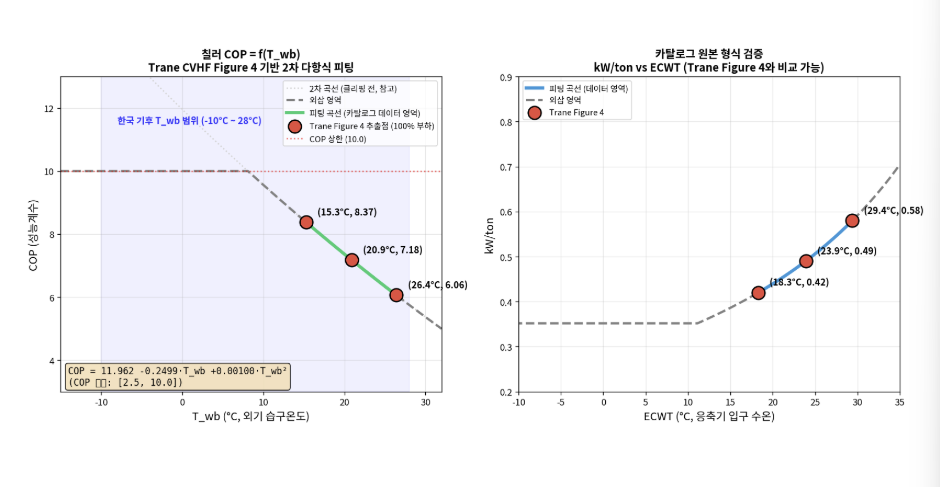

### 3.4.1 시각화 — COP & 칠러 소비전력 vs ECWT

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3.4.1 시각화 — Chiller COP 곡선 (T_wb 기반)
# 좌: T_wb vs COP (우리 모델)
# 우: kW/ton vs ECWT (Trane 카탈로그 원본 형식, 검증용)
# ═══════════════════════════════════════════════════════════════

# Trane Figure 4 원본 추출점 (검증용)
ECWT_orig  = np.array([18.3, 23.9, 29.4])
kWton_orig = np.array([0.42, 0.49, 0.58])
COP_orig   = 3.517 / kWton_orig
Twb_orig   = ECWT_orig - approach_CT  # T_wb로 변환

# 곡선 그릴 범위
twb_range = np.linspace(-15, 32, 300)
ch_curve  = f4_chiller(1000, twb_range)
COP_curve = ch_curve['COP']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── 좌: T_wb vs COP (우리 모델) ──
# 데이터 영역 / 외삽 영역 구분
mask_data    = (twb_range >= Twb_orig.min()) & (twb_range <= Twb_orig.max())
mask_extrap  = ~mask_data

# 외삽 영역 (점선 회색)
ax1.plot(twb_range[mask_extrap & (twb_range < Twb_orig.min())],
         COP_curve[mask_extrap & (twb_range < Twb_orig.min())],
         '--', color='gray', lw=2.5, label='외삽 영역')
ax1.plot(twb_range[mask_extrap & (twb_range > Twb_orig.max())],
         COP_curve[mask_extrap & (twb_range > Twb_orig.max())],
         '--', color='gray', lw=2.5)

# 데이터 영역 (초록 실선)
ax1.plot(twb_range[mask_data], COP_curve[mask_data],
         '-', color=C['chiller'], lw=3.5,
         label='피팅 곡선 (데이터 영역)')

# 원본 3점
ax1.scatter(Twb_orig, COP_orig, s=200, color=C['server'], zorder=5,
            edgecolor='black', linewidth=1.5,
            label='Trane Figure 4 추출점')
for tw, cop in zip(Twb_orig, COP_orig):
    ax1.annotate(f'  ({tw:.1f}°C, {cop:.2f})',
                 xy=(tw, cop), xytext=(8, 8),
                 textcoords='offset points', fontsize=10, fontweight='bold')

# COP 상한선
ax1.axhline(y=COP_max, color='red', ls=':', lw=1.5, alpha=0.6,
            label=f'COP 상한 ({COP_max})')

# 한국 기후 범위 음영
ax1.axvspan(-10, 28, alpha=0.06, color='blue', zorder=0)

ax1.set_xlabel('T_wb (°C, 외기 습구온도)', fontsize=12)
ax1.set_ylabel('COP', fontsize=12)
ax1.set_title('Chiller COP = f(T_wb)\n'
              'Trane CVHF Figure 4 기반 2차 피팅',
              fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(-15, 32)
ax1.set_ylim(3, 11.5)

# 식 표시
eq_text = f'COP = {COP_a:.3f} {COP_b:+.4f}·T_wb {COP_c:+.5f}·T_wb²\n범위: [{COP_min}, {COP_max}]'
ax1.text(0.02, 0.02, eq_text, transform=ax1.transAxes,
         fontsize=10, family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

# ── 우: kW/ton vs ECWT (카탈로그 원본 형식, 검증용) ──
ECWT_curve = twb_range + approach_CT
kWton_curve = 3.517 / COP_curve

ax2.plot(ECWT_curve[mask_data], kWton_curve[mask_data],
         '-', color=C['ct'], lw=3.5, label='피팅 곡선 (데이터 영역)')
ax2.plot(ECWT_curve[mask_extrap], kWton_curve[mask_extrap],
         '--', color='gray', lw=2.5, alpha=0.7, label='외삽 영역')

ax2.scatter(ECWT_orig, kWton_orig, s=200, color=C['server'], zorder=5,
            edgecolor='black', linewidth=1.5,
            label='Trane Figure 4 (100% 부하)')
for ec, kw in zip(ECWT_orig, kWton_orig):
    ax2.annotate(f'  ({ec:.1f}°C, {kw:.2f})',
                 xy=(ec, kw), xytext=(8, 8),
                 textcoords='offset points', fontsize=10, fontweight='bold')

ax2.set_xlabel('ECWT (°C, 응축기 입구 수온)', fontsize=12)
ax2.set_ylabel('kW/ton', fontsize=12)
ax2.set_title('카탈로그 원본 형식 검증\n'
              'kW/ton vs ECWT (Trane Figure 4 비교)',
              fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim(-10, 35)
ax2.set_ylim(0.2, 0.85)

plt.tight_layout()
plt.show()

---
## 4. 보조기기 동력 모델 — 펌프 3개 + 냉각탑 팬

$$W_{pump} = \frac{\dot{m} \times g \times H}{\eta_{pump} \times \eta_{motor}} \times \frac{1}{1000}\ \ [\text{kW}]$$

| 펌프 | 유량 (kg/s) | 수두 H (mAq) | 근거 |
|------|------------|-------------|------|
| TCS | 29.86 | 25 | 서버+CDU+배관 (D2C 수두 높음) |
| FWS | 39.82 | 20 | CDU+칠러 증발기+배관 |
| CWS | 가변 (Q_cond 의존) | 15 | 냉각탑+칠러 응축기+배관 |


In [ ]:
# Section 4 상단에 추가
_ch_design = f4_chiller(Q_IT_design, 20.0)
m_CWS_design = float(_ch_design['m_CWS'][0])  # ECWT=20 설계점



def calc_pump_power(m_dot, H_design, m_design):
    """
    펌프 소비전력 계산 — 유량 제곱 수두 보정 적용

    H = H_design × (m_dot / m_design)²   [배관 압력손실 ∝ V̇²]
    W = m_dot × g × H / (eta_pump × eta_motor × 1000)
    → 결과적으로 W ∝ m_dot³

    근거: Darcy-Weisbach, 유사법칙(Affinity Laws)
    설계점 기준: H_design @ m_design
    """
    H = H_design * (m_dot / m_design) ** 2
    return (m_dot * g * H) / (eta_pump * eta_motor * 1000)


def calc_aux_power(m_TCS, m_FWS, m_CWS):
    W_p_tcs = calc_pump_power(m_TCS, H_TCS_design, m_TCS_design)
    W_p_fws = calc_pump_power(m_FWS, H_FWS_design, m_FWS_design)
    W_p_cws = calc_pump_power(m_CWS, H_CWS_design, m_CWS_design)
    return {'W_pump_TCS': round(W_p_tcs, 2), 'W_pump_FWS': round(W_p_fws, 2),
            'W_pump_CWS': round(W_p_cws, 2), 'W_fan': W_fan_design,
            'W_aux_total': round(W_p_tcs + W_p_fws + W_p_cws + W_fan_design, 2)}


aux_d = calc_aux_power(s['m_TCS'], c['m_FWS'], f4_chiller(1000, 20)['m_CWS'][0])
print("-- Auxiliary Power (design point ECWT=20) --")
for k, v in aux_d.items(): print(f"  {k:20s} = {v:8.2f} kW")


In [ ]:
# ═══ CDU 온도차 민감도 분석 ═══
# dT_TCS, dT_FWS 변화 → m_dot 변화 → W_pump 변화 (∝ m³)

import numpy as np
import pandas as pd

# 분석 범위
dT_TCS_range = [4, 5, 6, 7, 8, 9, 10, 12]   # 설계점: 8°C
dT_FWS_range = [4, 5, 6, 7, 8, 9, 10, 12]   # 설계점: 6°C

print("=" * 65)
print("  CDU dT_TCS 민감도 (dT_FWS=6.0 고정)")
print("=" * 65)
print(f"  {'dT_TCS':>8} {'m_TCS':>10} {'H_TCS':>10} {'W_pump_TCS':>12} {'배율':>6}")
print("-" * 65)
W_base_TCS = calc_pump_power(m_TCS_design, H_TCS_design, m_TCS_design)
for dT in dT_TCS_range:
    m = Q_IT_design / (Cp * dT)
    W = calc_pump_power(m, H_TCS_design, m_TCS_design)
    H = H_TCS_design * (m / m_TCS_design) ** 2
    marker = " ← 설계점" if dT == 8.0 else ""
    print(f"  {dT:>8.1f} {m:>10.2f} {H:>10.2f} {W:>12.2f} {W/W_base_TCS:>6.2f}x{marker}")

print()
print("=" * 65)
print("  CDU dT_FWS 민감도 (dT_TCS=8.0 고정)")
print("=" * 65)
print(f"  {'dT_FWS':>8} {'m_FWS':>10} {'H_FWS':>10} {'W_pump_FWS':>12} {'배율':>6}")
print("-" * 65)
W_base_FWS = calc_pump_power(m_FWS_design, H_FWS_design, m_FWS_design)
for dT in dT_FWS_range:
    m = Q_IT_design / (Cp * dT)
    W = calc_pump_power(m, H_FWS_design, m_FWS_design)
    H = H_FWS_design * (m / m_FWS_design) ** 2
    marker = " ← 설계점" if dT == 6.0 else ""
    print(f"  {dT:>8.1f} {m:>10.2f} {H:>10.2f} {W:>12.2f} {W/W_base_FWS:>6.2f}x{marker}")

In [ ]:
W_base_TCS = calc_pump_power(m_TCS_design, H_TCS_design, m_TCS_design)
W_base_FWS = calc_pump_power(m_FWS_design, H_FWS_design, m_FWS_design)


import ipywidgets as widgets
from IPython.display import display

@widgets.interact(
    dT_TCS=widgets.FloatSlider(min=4, max=12, step=0.5, value=8.0, description='dT_TCS (°C)'),
    dT_FWS=widgets.FloatSlider(min=4, max=10, step=0.5, value=6.0, description='dT_FWS (°C)')
)
def show_pump_sensitivity(dT_TCS, dT_FWS):
    m_TCS = Q_IT_design / (Cp * dT_TCS)
    m_FWS = Q_IT_design / (Cp * dT_FWS)
    W_TCS = calc_pump_power(m_TCS, H_TCS_design, m_TCS_design)
    W_FWS = calc_pump_power(m_FWS, H_FWS_design, m_FWS_design)

    print(f"  m_TCS       = {m_TCS:.2f} kg/s  (설계점 {m_TCS_design:.2f})")
    print(f"  W_pump_TCS  = {W_TCS:.2f} kW   (설계점 {W_base_TCS:.2f}, 배율 {W_TCS/W_base_TCS:.2f}x)")
    print()
    print(f"  m_FWS       = {m_FWS:.2f} kg/s  (설계점 {m_FWS_design:.2f})")
    print(f"  W_pump_FWS  = {W_FWS:.2f} kW   (설계점 {W_base_FWS:.2f}, 배율 {W_FWS/W_base_FWS:.2f}x)")

dT_TCS = 8°C

서버 ↔ CDU 사이 온도차

서버에서 나온 물 30°C → CDU 통과 → 22°C로 식혀서

서버로 복귀

차이: 30 - 22 = 8°C

근거: OCP D2C 권장범위

dT_FWS = 6°C

CDU ↔ 칠러 사이 온도차

칠러에서 나온 물 17°C → CDU 통과 → 23°C로 데워져서 칠러로 복귀

차이: 23 - 17 = 6°C

근거: ASHRAE TC 9.9 W17

dT 줄이면 → 유량 늘어야 같은 열량 처리 가능
dT 늘리면 → 유량 줄어도 같은 열량 처리 가능

---
## 5. 시스템 통합 — 전체 루프 연결 & PUE 도출

$$\text{PUE} = \frac{Q_{IT} + W_{chiller} + W_{pump,TCS} + W_{pump,FWS} + W_{pump,CWS} + W_{fan}}{Q_{IT}}$$


In [ ]:
#  T_wb = 17°C 단일 시점이 기준

def run_system(Q_IT, T_wb):
    T_wb = np.atleast_1d(np.asarray(T_wb, dtype=float))
    n = len(T_wb)
    srv = f1_server(Q_IT)
    cdu = f2_cdu(srv['T_TCS_return'], Q_IT)
    ct  = f3_cooling_tower(T_wb)
    ch  = f4_chiller(cdu['Q_CDU'], ct['ECWT'])
    # Aux
    W_p_tcs = np.full(n, calc_pump_power(srv['m_TCS'], H_TCS_design, m_TCS_design))
    W_p_fws = np.full(n, calc_pump_power(cdu['m_FWS'], H_FWS_design, m_FWS_design))
    W_p_cws = np.array([calc_pump_power(m, H_CWS_design, m_CWS_design) for m in ch['m_CWS']])
    W_fan   = np.full(n, W_fan_design)
    W_aux   = W_p_tcs + W_p_fws + W_p_cws + W_fan
    W_total = ch['W_chiller'] + W_aux
    PUE = (Q_IT + W_total) / Q_IT
    return {'Q_IT':Q_IT, 'T_wb':T_wb, 'ECWT':ct['ECWT'], 'COP':ch['COP'],
            'W_chiller':ch['W_chiller'], 'W_pump_TCS':W_p_tcs, 'W_pump_FWS':W_p_fws,
            'W_pump_CWS':W_p_cws, 'W_fan':W_fan, 'W_aux':np.round(W_aux,2),
            'W_total':np.round(W_total,2), 'Q_cond':ch['Q_cond'], 'm_CWS':ch['m_CWS'],
            'PUE':np.round(PUE,4)}

d = run_system(1000, 17.0)
print("=" * 55)
print("  System Integration (T_wb=17, ECWT=20)")
print("=" * 55)
print(f"  ECWT        = {d['ECWT'][0]:7.1f} C")
print(f"  COP         = {d['COP'][0]:7.3f}")
print(f"  W_chiller   = {d['W_chiller'][0]:7.1f} kW")
print(f"  W_pump_TCS  = {d['W_pump_TCS'][0]:7.1f} kW")
print(f"  W_pump_FWS  = {d['W_pump_FWS'][0]:7.1f} kW")
print(f"  W_pump_CWS  = {d['W_pump_CWS'][0]:7.1f} kW")
print(f"  W_fan       = {d['W_fan'][0]:7.1f} kW")
print(f"  ---------------------")
print(f"  W_total     = {d['W_total'][0]:7.1f} kW")
print(f"  PUE         = {d['PUE'][0]:7.4f}")
print(f"  Ref: KT Gasan PUE = 1.30")
print("=" * 55)


In [ ]:
import inspect
print(inspect.signature(calc_pump_power))

### 5.1 에너지 흐름 요약

에너지 보존이 모든 노드에서 성립함을 확인합니다.


In [ ]:
print(f'''
  [Power Input]                    [Heat Flow]
   Q_IT       = {d['Q_IT']:>8,.1f} kW     Server  -> {d['Q_IT']:>8,.1f} kW -> CDU
   W_chiller  = {d['W_chiller'][0]:>8.1f} kW     CDU     -> {d['Q_IT']:>8,.1f} kW -> Chiller
   W_pump_TCS = {d['W_pump_TCS'][0]:>8.1f} kW     Chiller -> {d['Q_cond'][0]:>8.1f} kW -> CT
   W_pump_FWS = {d['W_pump_FWS'][0]:>8.1f} kW     CT      -> {d['Q_cond'][0]:>8.1f} kW -> Outdoor
   W_pump_CWS = {d['W_pump_CWS'][0]:>8.1f} kW
   W_fan      = {d['W_fan'][0]:>8.1f} kW     Energy conservation:
   -----------------------          Q_cond = Q_CDU + W_chiller
   Total      = {d['Q_IT']+d['W_total'][0]:>8.1f} kW        = {d['Q_IT']:.0f} + {d['W_chiller'][0]:.1f} = {d['Q_cond'][0]:.1f} kW

   COP = {d['COP'][0]:.3f}    PUE = {d['PUE'][0]:.4f}    (KT Gasan = 1.30)
''')


---
## 6. PUE 도출 과정 — 인과 사슬 시각화

**교수님께 보여드릴 핵심 그래프.** T_wb → ECWT → COP → W → PUE 인과 관계.


In [ ]:
twb_r = np.linspace(-5, 28, 200)
sys_r = run_system(1000, twb_r)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax=axes[0,0]
ax.plot(twb_r, sys_r['ECWT'], '-', color=C['ct'], lw=2.5)
ax.set_xlabel('T_wb (C)'); ax.set_ylabel('ECWT (C)')
ax.set_title('(a) Cooling Tower\nECWT = T_wb + 3', fontweight='bold'); ax.grid(alpha=0.3)

ax=axes[0,1]
ax.plot(twb_r, sys_r['COP'], '-', color=C['chiller'], lw=2.5)
ax.set_xlabel('T_wb (C)'); ax.set_ylabel('COP')
ax.set_title('(b) Chiller COP\nf(ECWT), quadratic, W17', fontweight='bold'); ax.grid(alpha=0.3)

ax=axes[1,0]
ax.fill_between(twb_r,0,sys_r['W_chiller'],alpha=0.6,color=C['chiller'],label='Chiller')
W_pumps = sys_r['W_pump_TCS']+sys_r['W_pump_FWS']+sys_r['W_pump_CWS']
ax.fill_between(twb_r,sys_r['W_chiller'],sys_r['W_chiller']+W_pumps,
                alpha=0.6,color=C['pump'],label='Pumps(3)')
ax.fill_between(twb_r,sys_r['W_chiller']+W_pumps,sys_r['W_total'],
                alpha=0.6,color=C['fan'],label='Fan')
ax.set_xlabel('T_wb (C)'); ax.set_ylabel('Power (kW)')
ax.set_title('(c) Cooling Power Breakdown\nChiller + Pumps + Fan',fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax=axes[1,1]
ax.plot(twb_r, sys_r['PUE'], '-', color=C['pue'], lw=3)
ax.axhline(y=1.30,color='red',ls='--',alpha=0.6,lw=1.5,label='KT Gasan PUE=1.30')
ax.fill_between(twb_r,1.0,sys_r['PUE'],alpha=0.1,color=C['pue'])
ax.set_xlabel('T_wb (C)'); ax.set_ylabel('PUE')
ax.set_title('(d) PUE = (Q_IT + W_total) / Q_IT\nFull model',fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylim(1.0,1.40)

plt.suptitle('KFC Model v1.0 — T_wb -> ECWT -> COP -> W -> PUE',
             fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()


---
## 7. 춘천 연간 PUE 프로파일 (실측 8,760h)

기상청 KMA 시간별 관측값 기반. Section 0에서 로드한 `climate_data['춘천']` 사용.


In [ ]:
REGION = '춘천'
# 춘천 실측 8,760h 시뮬레이션
df_cc = climate_data[REGION].copy()
sys_cc = run_system(Q_IT_design, np.array(df_cc['T_wb']))

# ── 연계 검증 ──
# 특정 시간 하나 골라서 수동 계산과 비교

idx = 0  # 첫 번째 행
t_wb_sample = df_cc['T_wb'].iloc[idx]
manual = run_system(Q_IT_design, np.array([t_wb_sample]))

print(f'[검증] index={idx}, datetime={df_cc["datetime"].iloc[idx]}')
print(f'  T_wb         = {t_wb_sample:.3f} °C')
print(f'  ECWT         = {manual["ECWT"][0]:.3f} °C  (= T_wb + 3)')
print(f'  COP          = {manual["COP"][0]:.3f}')
print(f'  W_chiller    = {manual["W_chiller"][0]:.2f} kW')
print(f'  PUE          = {manual["PUE"][0]:.4f}')
print(f'  sys_cc PUE[{idx}] = {sys_cc["PUE"][idx]:.4f}  ← 일치하면 연계 확인 ✓')

In [ ]:
# ── Section 5.1 — 시스템 통합 포인트 검증 (ipywidgets) ──
import ipywidgets as widgets
from IPython.display import display, clear_output

w_region = widgets.Dropdown(
    options=list(climate_data.keys()),
    value='춘천',
    description='지역',
)
w_month = widgets.IntSlider(min=1, max=12, value=8,  description='월')
w_day   = widgets.IntSlider(min=1, max=31, value=1,  description='일')
w_hour  = widgets.IntSlider(min=0, max=23, value=14, description='시')
out     = widgets.Output()

def query(_):
    with out:
        clear_output(wait=True)

        df_q = climate_data[w_region.value].copy()
        df_q['datetime'] = pd.to_datetime(df_q['datetime'])
        mask = (
            (df_q['datetime'].dt.month == w_month.value) &
            (df_q['datetime'].dt.day   == w_day.value)   &
            (df_q['datetime'].dt.hour  == w_hour.value)
        )
        row = df_q[mask]

        if row.empty:
            print(f"⚠ 데이터 없음: {w_region.value} "
                  f"{w_month.value}/{w_day.value} {w_hour.value:02d}:00")
            return

        r   = row.iloc[0]
        idx = row.index[0]

        # ── 시스템 시뮬레이션 ──
        res = run_system(Q_IT_design, np.array([r['T_wb']]))

        # ── 연간 배열과 일치 확인 ──
        sys_full = run_system(Q_IT_design, np.array(df_q['T_wb']))

        print(f"{'='*52}")
        print(f"  {w_region.value}  "
              f"{w_month.value:02d}/{w_day.value:02d}  {w_hour.value:02d}:00")
        print(f"{'='*52}")
        print(f"  [기상 입력]")
        print(f"  T_db        = {r['T_db']:7.3f} °C")
        print(f"  RH          = {r['RH']:7.1f} %")
        print(f"  Pressure    = {r['pressure']:7.1f} hPa")
        print(f"  T_wb        = {r['T_wb']:7.3f} °C   ← psychrolib")
        print(f"{'─'*52}")
        print(f"  [인과 사슬]  T_wb → ECWT → COP → W → PUE")
        print(f"  ECWT        = {res['ECWT'][0]:7.3f} °C   (= T_wb + {approach_CT})")
        print(f"  COP         = {res['COP'][0]:7.3f}")
        print(f"{'─'*52}")
        print(f"  [전력 분해]")
        print(f"  W_chiller   = {res['W_chiller'][0]:7.2f} kW")
        print(f"  W_pump_TCS  = {res['W_pump_TCS'][0]:7.2f} kW")
        print(f"  W_pump_FWS  = {res['W_pump_FWS'][0]:7.2f} kW")
        print(f"  W_pump_CWS  = {res['W_pump_CWS'][0]:7.2f} kW")
        print(f"  W_fan       = {res['W_fan'][0]:7.2f} kW")
        print(f"  W_total     = {res['W_total'][0]:7.2f} kW")
        print(f"{'─'*52}")
        print(f"  PUE         = {res['PUE'][0]:7.4f}")
        print(f"{'─'*52}")
        print(f"  [연계 검증]")
        print(f"  연간 배열 PUE[{idx}] = {sys_full['PUE'][idx]:.4f}  "
              f"{'✓ 일치' if abs(res['PUE'][0] - sys_full['PUE'][idx]) < 1e-6 else '❌ 불일치'}")
        print(f"{'='*52}")

for w in [w_region, w_month, w_day, w_hour]:
    w.observe(query, names='value')

display(widgets.VBox([
    widgets.HBox([w_region]),
    widgets.HBox([w_month, w_day, w_hour]),
    out
]))
query(None)

In [ ]:
from ipywidgets import interact, Dropdown

@interact(지역=Dropdown(options=['춘천','구미','세종','울산','해남']))
def run_region(지역):
    global df_cc, sys_cc, monthly

    df_cc = climate_data[지역].copy()
    sys_cc = run_system(Q_IT_design, np.array(df_cc['T_wb']))

    #df_cc['month']   = pd.to_datetime(df_cc['datetime']).dt.month
    df_cc['dt']    = pd.to_datetime(df_cc['datetime'])
    df_cc['month'] = df_cc['dt'].dt.month
    df_cc['PUE']     = sys_cc['PUE']
    df_cc['W_total'] = sys_cc['W_total']

    monthly = df_cc.groupby('month').agg(
        T_wb_mean=('T_wb','mean'),
        PUE_mean=('PUE','mean'),
        PUE_max=('PUE','max'),
        W_total_sum=('W_total','sum')
    ).reset_index()
    monthly['Month'] = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

    print(f'\n{지역} 연간 평균 PUE    = {df_cc["PUE"].mean():.4f}')
    print(f'{지역} 여름 최대 PUE    = {df_cc["PUE"].max():.4f}')
    print(f'{지역} 겨울 최소 PUE    = {df_cc["PUE"].min():.4f}')
    print(f'{지역} 연간 냉각 전력량 = {df_cc["W_total"].sum():,.0f} kWh')

    # ── 시각화 ──
    fig, ax1 = plt.subplots(figsize=(13,6))
    x = range(12)
    bars = ax1.bar(x, monthly['PUE_mean'], width=0.6, color=C['pue'],
                   alpha=0.7, edgecolor='white', lw=1.5)
    for b, p in zip(bars, monthly['PUE_mean']):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                 f'{p:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax1.axhline(y=1.30, color='red', ls='--', alpha=0.6, lw=1.5, label='KT Gasan=1.30')
    ax1.set_ylim(1.0, 1.40); ax1.set_ylabel('PUE', fontsize=12)
    ax2 = ax1.twinx()
    ax2.plot(x, monthly['T_wb_mean'], 'o-', color=C['ct'], lw=2, ms=6, label='T_wb average')
    ax2.set_ylabel('T_wb (°C)', fontsize=12)
    ax1.set_xticks(x); ax1.set_xticklabels(monthly['Month'])
    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
    ax1.set_title(f'{지역} annual PUE (actual measurement 8,760h)\n'  # ← 지역명 변수로
                  f'Mean={df_cc["PUE"].mean():.4f} | Q_IT={Q_IT_design:.0f}kW',
                  fontweight='bold')
    ax1.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

    # ── 일별 집계 ──
    daily = df_cc.groupby(df_cc['dt'].dt.date).agg(
        T_wb_mean=('T_wb','mean'),
        PUE_mean=('PUE','mean'),
        PUE_max=('PUE','max'),
        W_total_sum=('W_total','sum')
    ).reset_index()

    # ── 일별 시각화 ──
    fig, ax = plt.subplots(figsize=(15,4))
    ax.plot(daily['dt'], daily['PUE_mean'], lw=0.8, color=C['pue'], label='일별 PUE')
    ax.axhline(y=1.30, color='red', ls='--', alpha=0.6, lw=1.5, label='KT Gasan=1.30')
    ax.set_ylabel('PUE', fontsize=12)
    ax.set_title(f'{지역} 일별 PUE (2025)\nMin={daily["PUE_mean"].min():.4f} | Max={daily["PUE_mean"].max():.4f}',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── 날짜별 시간 PUE ──
from ipywidgets import interact, Dropdown

# 날짜 목록 생성 (2025년 전체)
dates = sorted(df_cc['dt'].dt.date.unique())
date_options = [str(d) for d in dates]

@interact(날짜=Dropdown(options=date_options, value='2025-08-01', description='날짜'))
def daily_pue(날짜):
    df_day = df_cc[df_cc['dt'].dt.strftime('%Y-%m-%d') == 날짜].copy()

    if len(df_day) == 0:
        print('데이터 없음')
        return

    fig, ax1 = plt.subplots(figsize=(13,5))
    x = range(len(df_day))

    ax1.plot(x, df_day['PUE'].values, 'o-', color=C['pue'], lw=2, ms=6, label='PUE')
    ax1.axhline(y=1.30, color='red', ls='--', alpha=0.6, lw=1.5, label='KT Gasan=1.30')
    ax1.set_ylabel('PUE', fontsize=12)
    ax1.set_ylim(1.0, 1.40)

    ax2 = ax1.twinx()
    ax2.plot(x, df_day['T_wb'].values, 's--', color=C['ct'], lw=1.5, ms=5, label='T_wb')
    ax2.set_ylabel('T_wb (°C)', fontsize=12)

    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{h:02d}:00' for h in range(len(df_day))], rotation=45, fontsize=8)

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
    ax1.set_title(f'{지역} {날짜} 시간별 PUE\n'
                  f'일평균={df_day["PUE"].mean():.4f} | '
                  f'T_wb {df_day["T_wb"].min():.1f}~{df_day["T_wb"].max():.1f}°C',
                  fontweight='bold')
    ax1.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── 날짜별 시간 PUE ──
from ipywidgets import interact, Dropdown

@interact(
    지역=Dropdown(options=list(climate_data.keys()), value='춘천', description='지역'),
    날짜=Dropdown(options=date_options, value='2025-08-01', description='날짜')
)
def daily_pue(지역, 날짜):
    df_cc = climate_data[지역].copy()
    df_cc['dt'] = pd.to_datetime(df_cc['datetime'])
    sys_cc = run_system(Q_IT_design, np.array(df_cc['T_wb']))
    df_cc['PUE'] = sys_cc['PUE']

    df_day = df_cc[df_cc['dt'].dt.strftime('%Y-%m-%d') == 날짜].copy()

    if len(df_day) == 0:
        print('데이터 없음')
        return

    fig, ax1 = plt.subplots(figsize=(13, 5))
    x = range(len(df_day))

    ax1.plot(x, df_day['PUE'].values, 'o-', color=C['pue'], lw=2, ms=6, label='PUE')
    ax1.axhline(y=1.30, color='red', ls='--', alpha=0.6, lw=1.5, label='KT Gasan=1.30')
    ax1.set_ylabel('PUE', fontsize=12)
    ax1.set_ylim(1.0, 1.40)

    ax2 = ax1.twinx()
    ax2.plot(x, df_day['T_wb'].values, 's--', color=C['ct'], lw=1.5, ms=5, label='T_wb')
    ax2.set_ylabel('T_wb (°C)', fontsize=12)

    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{h:02d}:00' for h in range(len(df_day))], rotation=45, fontsize=8)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=9)
    ax1.set_title(f'{지역} {날짜} 시간별 PUE\n'
                  f'일평균={df_day["PUE"].mean():.4f} | '
                  f'T_wb {df_day["T_wb"].min():.1f}~{df_day["T_wb"].max():.1f}°C',
                  fontweight='bold')
    ax1.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [ ]:
# 춘천 겨울 ECWT 최솟값 확인
df = climate_data['춘천']
sys = run_system(Q_IT_design, np.array(df['T_wb']))
print(f'ECWT 최솟값: {sys["ECWT"].min():.1f}°C')
print(f'COP 최솟값:  {sys["COP"].min():.3f}')
print(f'COP 최댓값:  {sys["COP"].max():.3f}')
print(f'COP=10 클리핑 발생 시간: {(sys["COP"] >= 10.0).sum()}h')

# 여름 ECWT 최댓값에서 COP 확인
print(f'ECWT 최댓값: {sys_cc["ECWT"].max():.1f}°C')
print(f'그때 COP: {sys_cc["COP"][sys_cc["ECWT"].argmax()]:.3f}')



# COP 최솟값과 최댓값은 확실히 확인하여 설정에 반영 필요.

In [ ]:
import matplotlib.gridspec as gridspec

# Define a default REGION for standalone execution
지역 = '춘천'

# ── 1. T_wb vs COP 산점도 (8,760h 전체) ──
fig, ax = plt.subplots(figsize=(10,6))
twb_all = np.array(df_cc['T_wb'])
cop_all = run_system(Q_IT_design, twb_all)['COP']
sc = ax.scatter(twb_all, cop_all, c=twb_all, cmap='RdYlBu_r',
                s=2, alpha=0.4)
plt.colorbar(sc, ax=ax, label='T_wb (°C)')
ax.set_xlabel('T_wb (°C)', fontsize=12)
ax.set_ylabel('COP', fontsize=12)
ax.set_title(f'{지역} T_wb → COP (8,760h 전체)\n인과관계 검증',
             fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ── 2. PUE 히트맵 (월 × 시간대) ──
df_heat = df_cc.copy()
df_heat['hour'] = df_heat['dt'].dt.hour
pivot = df_heat.pivot_table(values='PUE', index='hour', columns='month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14,6))
im = ax.imshow(pivot, aspect='auto', cmap='RdYlBu_r',
               vmin=pivot.values.min(), vmax=pivot.values.max())
plt.colorbar(im, ax=ax, label='PUE')
ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(24))
ax.set_yticklabels([f'{h:02d}:00' for h in range(24)], fontsize=7)
ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('시간대', fontsize=12)
ax.set_title(f'{지역} PUE 히트맵 (월 × 시간대)\n빨강=높음(여름낮), 파랑=낮음(겨울새벽)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. 5개 지역 PUE 박스플롯 ──
fig, ax = plt.subplots(figsize=(12,6))
box_data = []
labels = []
for name, df in climate_data.items():
    sys = run_system(Q_IT_design, np.array(df['T_wb']))
    box_data.append(sys['PUE'])
    labels.append(name)

bp = ax.boxplot(box_data, labels=labels, patch_artist=True,
                medianprops=dict(color='white', lw=2))
colors = [C['server'], C['cdu'], C['ct'], C['chiller'], C['pump']]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(y=1.30, color='red', ls='--', alpha=0.6, lw=1.5, label='KT Gasan=1.30')
ax.set_ylabel('PUE', fontsize=12)
ax.set_title('5개 지역 PUE 분포 비교 (실측 8,760h)\nQ_IT=1,000kW',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

---
## 8. 냉각 전력 구성 분석

In [ ]:
# ── Section 8. 냉각 전력 구성 분석 ──
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))

# Pie — 설계점 (ECWT=20 고정)
d_design = run_system(Q_IT_design, np.array([17.0]))  # T_wb=17 → ECWT=20
labels=['Chiller','Pump_TCS','Pump_FWS','Pump_CWS','Fan']
vals=[d_design['W_chiller'][0], d_design['W_pump_TCS'][0],
      d_design['W_pump_FWS'][0], d_design['W_pump_CWS'][0], d_design['W_fan'][0]]
cs=[C['chiller'],C['server'],C['cdu'],C['pump'],C['fan']]
ax1.pie(vals,labels=labels,colors=cs,
        autopct=lambda p:f'{p:.1f}%\n({p*sum(vals)/100:.1f}kW)',
        startangle=90,pctdistance=0.72)
ax1.set_title(f'Design Point (ECWT=20)\nTotal={sum(vals):.1f}kW',fontweight='bold')

# Stacked bar — 선택된 지역 월별 breakdown
bottom=np.zeros(12)
for lbl,v,clr in [('Chiller',sys_cc['W_chiller'],C['chiller']),
                   ('Pumps',sys_cc['W_pump_TCS']+sys_cc['W_pump_FWS']+sys_cc['W_pump_CWS'],C['pump']),
                   ('Fan',sys_cc['W_fan'],C['fan'])]:
    monthly_v = [v[df_cc['month']==m].mean() for m in range(1,13)]
    ax2.bar(range(12),monthly_v,width=0.6,bottom=bottom,color=clr,alpha=0.8,label=lbl)
    bottom+=np.array(monthly_v)
ax2.set_xticks(range(12))
ax2.set_xticklabels(monthly['Month'],fontsize=9)
ax2.set_ylabel('Power (kW)')
ax2.set_title(f'{지역} Monthly Breakdown',fontweight='bold')
ax2.legend(fontsize=9);ax2.grid(axis='y',alpha=0.2)
plt.tight_layout();plt.show()


---
## 9. KMA 기상 데이터 연결 — 5개 지역 연간 시뮬레이션

Section 0에서 로드한 `climate_data` (각 지역 8,760h 실측) 를 `run_system()`에 직접 투입합니다.


In [ ]:
# ── 5개 지역 연간 시뮬레이션 (8,760h) ──
annual_results = {}
for name, df in climate_data.items():
    twb = np.array(df['T_wb'])
    sys = run_system(Q_IT_design, twb)
    annual_results[name] = {
        'PUE_mean':         round(float(sys['PUE'].mean()), 4),
        'PUE_max':          round(float(sys['PUE'].max()),  4),
        'PUE_min':          round(float(sys['PUE'].min()),  4),
        'W_annual_kWh':     round(float(sys['W_total'].sum()), 0),
        'T_wb_mean':        round(float(twb.mean()), 2),
        'T_wb_summer_max':  round(float(twb.max()),  1),
        'T_wb_winter_min':  round(float(twb.min()),  1),
    }
    print(f'{name}: PUE_mean={annual_results[name]["PUE_mean"]:.4f} | '
          f'연간냉각={annual_results[name]["W_annual_kWh"]:,.0f} kWh')

res_df = pd.DataFrame(annual_results).T.reset_index().rename(columns={'index':'지역'})
print()
print(res_df.to_string(index=False))


### 9.1 5개 지역 PUE 비교 시각화 (실측 8,760h)

In [ ]:
comp = []
for name, r in annual_results.items():
    comp.append({'Region': name,
                 'PUE_mean': r['PUE_mean'],
                 'PUE_max':  r['PUE_max'],
                 'PUE_min':  r['PUE_min']})


In [ ]:
fig,ax=plt.subplots(figsize=(10,6))
xp=np.arange(len(comp))
means=[r['PUE_mean'] for r in comp]; mins=[r['PUE_min'] for r in comp]
maxs=[r['PUE_max'] for r in comp]; names=[r['Region'] for r in comp]
ax.bar(xp,means,width=0.5,color=C['pue'],alpha=0.8,edgecolor='white',lw=1.5)
ax.vlines(xp,mins,maxs,color='gray',lw=2,label='Min-Max')
ax.scatter(xp,mins,color=C['ct'],s=60,zorder=5,label='Winter min')
ax.scatter(xp,maxs,color=C['server'],s=60,zorder=5,label='Summer max')
for i,m in enumerate(means):
    ax.text(i,m+0.003,f'{m:.3f}',ha='center',fontsize=10,fontweight='bold')
ax.axhline(y=1.30,color='red',ls='--',alpha=0.5,label='KT Gasan=1.30')
ax.set_xticks(xp);ax.set_xticklabels(names,fontsize=11)
ax.set_ylabel('PUE');ax.set_ylim(1.0,1.40)
ax.set_title('5-Region PUE Comparison (실측 8,760h)\nQ_IT=1000kW',fontweight='bold')
ax.legend(fontsize=9);ax.grid(axis='y',alpha=0.2);plt.tight_layout();plt.show()


---
## 10. 모델 상태 정리

### KFC Model v3.0
| 컴포넌트 | 구현 | 검증 |
|----------|------|------|
| f1_server() | ✅ | 에너지 밸런스 ✓ |
| f2_cdu() | ✅ | 대향류 approach ✓ |
| f3_cooling_tower() | ✅ | T_wb→ECWT ✓ |
| f4_chiller() | ✅ | COP 3~10 ✓ |
| W_pump (TCS, FWS, CWS) | ✅ | 수두 기반 ✓ |
| W_fan | ✅ | 20kW 고정 ✓ |
| PUE 산출 | ✅ | KT Gasan 1.30 기준 ✓ |
| KMA CSV 로더 | ✅ | 5개 지역 8,760h ✓ |
| 습구온도 계산 (Stull 2011) | ✅ | T_db + RH → T_wb ✓ |
| 결측 보간 | ✅ | 선형보간 (춘천 50h 대응) ✓ |

### 다음 단계
| 항목 | 우선순위 |
|------|---------|
| Free Cooling (PHE) 전환 로직 | **1순위** |
| Case A vs B 에너지 절감량 비교 | 2순위 |
| LCC 분석 연결 | 3순위 |


---
## 6. Free Cooling 적용 (후처리 방식)**설계 원리**- 매 시간 외기 T_wb로부터 ECWT(T_wb)를 계산 (v3의 f3_cooling_tower 재활용)- FC 가용 조건: `ECWT + approach_PHE ≤ T_FWS_supply (17°C)`- 가용 시간대: 칠러 OFF, PHE가 FWS를 직접 냉각- 불가 시간대: v3 baseline 그대로 (칠러 ON)**민감도 분석**- approach_PHE: 1°C (공격적) / 2°C (기준) / 3°C (보수적)- 기준 케이스(2°C)는 ASHRAE 90.1-2013 §6.5.1.2 의무 설계점  (50°F DB / 45°F WB ≈ 7.2°C에서 100% FC 가능)과 정합**후처리 방식 채택 이유**- v3 baseline은 한 번 계산되고 그대로 보존됨 → 추적성 ↑- approach_PHE 케이스별로 baseline 재계산 불필요 → 효율 ↑- v3 영역과 FC 영역 코드 분리 → 리뷰/디버깅 용이**1차 단순화 가정 (한계점)**- partial FC 미고려 (이분법): 절감률을 보수적으로 추정- CT 부분부하 영향 미고려 (Schwedler 100% 부하 곡선 사용)- CT 최저 운영온도 제한 미고려 (현 모델 결과에 영향 미미)- W_fan 20kW 고정 (FC/Chiller 모드 동일)- dT_CWS = 5°C 유지 (FC 모드에서도)

In [ ]:
# ═══ Section 6.1 — Free Cooling 설계 상수 ═══
# v3 Section 2(설계 상수)와 분리하여 FC 관련 상수만 격리 관리

# approach_PHE 민감도 케이스
# 출처: AHRI 400 (PHE 표준), ASHRAE 90.1-2013 §6.5.1
#       Deppmann WSE 시리즈 (3°F ≈ 1.7°C 예시), DOE Best Practices (<3°F)
APPROACH_PHE_CASES = {
    'aggressive':   1.0,   # °C, 고효율 GPHX 큰 면적 (낙관적)
    'reference':    2.0,   # °C, 표준 (ASHRAE 90.1 의무점 7.2°C와 정합)
    'conservative': 3.0,   # °C, 일반 PHE 작은 면적 (보수적)
}

# FC 모드 추가 압력손실 (모든 케이스 공통, 1차 단순화)
# 출처: Alfa Laval 등 GPHX 카탈로그 일반값 (3~5 mAq), 중간값 채택
H_CWS_FC_extra = 5.0   # mAq

# FC 모드 dT_CWS 가정 (1차 단순화, 합의됨)
# - PHE 물리로 산출하면 시간별 가변이지만, 1차 단순화로 5°C 유지
# - 펌프 운전 일관성 확보, 결과 해석 단순화
dT_CWS_FC = dT_CWS     # = 5.0°C (v3 상수 재사용)

print("=" * 60)
print("  Free Cooling 설계 상수 로드 완료")
print("=" * 60)
print(f"  approach_PHE 케이스:")
for name, val in APPROACH_PHE_CASES.items():
    print(f"    {name:13s} : {val}°C")
print(f"  H_CWS_FC_extra : {H_CWS_FC_extra} mAq")
print(f"  dT_CWS_FC      : {dT_CWS_FC}°C  (= v3 dT_CWS 유지)")
print(f"  T_FWS_supply   : {T_FWS_supply}°C  (= v3, ASHRAE TC 9.9 W17)")
print("=" * 60)

In [ ]:
# ═══ Section 6.2 — FC 가용성 판단 함수 ═══

def f_fc_availability(T_wb, approach_PHE):
    """
    Free Cooling 가용성 판단 — 시간별 bool array 반환

    물리적 조건 (3단계 직렬 열저항):
        T_wb  →  +approach_CT(T_wb)  →  ECWT
        ECWT  →  +approach_PHE       →  T_PHE_out (FWS측)
        FC 가용 ⟺ T_PHE_out ≤ T_FWS_supply (17°C)

    Args:
        T_wb         : 시간별 습구온도 array (°C)
        approach_PHE : PHE approach (민감도 분석용, °C)

    Returns:
        dict with arrays:
            fc_available : bool, 시간별 FC 가용 여부
            ECWT         : 냉각탑 출구수 온도
            T_PHE_out    : PHE 출구 (FWS측) 온도
            margin       : T_FWS_supply - T_PHE_out (양수면 가용, 여유 ↑)
    """
    T_wb = np.atleast_1d(np.asarray(T_wb, dtype=float))

    # v3의 f3_cooling_tower 재활용 — ECWT(T_wb) 가변 approach 모델
    ct = f3_cooling_tower(T_wb)
    ECWT = ct['ECWT']

    # PHE 출구 온도 (FWS측 공급)
    T_PHE_out = ECWT + approach_PHE

    # FC 가용 마진
    margin = T_FWS_supply - T_PHE_out
    fc_available = margin >= 0   # bool array

    return {
        'fc_available': fc_available,
        'ECWT':         np.round(ECWT, 2),
        'T_PHE_out':    np.round(T_PHE_out, 2),
        'margin':       np.round(margin, 2),
    }


# ── 검증: 단일 포인트 3개 (T_wb = 0°C, 7°C, 20°C) × 3개 케이스 ──
print("-- f_fc_availability() 검증 (3 T_wb × 3 approach_PHE) --\n")
twb_test = np.array([0.0, 7.0, 20.0])
print(f"{'T_wb':>6s} {'ECWT':>7s} | "
      f"{'PHE=1°C':>14s} | {'PHE=2°C':>14s} | {'PHE=3°C':>14s}")
print("-" * 75)
for twb in twb_test:
    row = f"{twb:>5.1f}°C"
    ecwt = f3_cooling_tower(np.array([twb]))['ECWT'][0]
    row += f" {ecwt:>6.2f}°C |"
    for case_name, phe in APPROACH_PHE_CASES.items():
        res = f_fc_availability(np.array([twb]), phe)
        flag = '✓ FC' if res['fc_available'][0] else '✗ Chiller'
        row += f" {flag:>9s} m={res['margin'][0]:+5.1f} |"
    print(row)
print()
print("  → 임계 T_wb (이 이하에서 FC 가능):")
for case_name, phe in APPROACH_PHE_CASES.items():
    twb_grid = np.linspace(-15, 25, 4001)
    fc = f_fc_availability(twb_grid, phe)
    if fc['fc_available'].any():
        twb_crit = twb_grid[fc['fc_available']].max()
        print(f"    approach_PHE = {phe}°C → T_wb ≤ {twb_crit:.2f}°C")

In [ ]:
# ═══ Section 6.3 — FC 후처리 오버레이 함수 ═══
#
# 입력: v3 baseline 시계열 (run_system 결과) + T_wb + approach_PHE
# 출력: FC 적용 후 시계열
#
# 동작:
#   1. 매 시간 FC 가용성 판단
#   2. FC 가용 시간대만 FC 모드로 덮어쓰기 (overlay)
#   3. FC 불가 시간대는 baseline 그대로 유지

def apply_fc_overlay(baseline, T_wb, approach_PHE, Q_IT=Q_IT_design):
    """
    v3 baseline 시계열에 FC 모드를 오버레이

    Args:
        baseline      : v3 run_system(Q_IT, T_wb) 결과 dict
        T_wb          : 시간별 습구온도 array (baseline과 동일 길이)
        approach_PHE  : PHE approach (°C)
        Q_IT          : IT 부하 (kW, default 설계점)

    Returns:
        FC 적용 시계열 dict (baseline과 동일 키 구조 + 추가 필드)
    """
    T_wb = np.atleast_1d(np.asarray(T_wb, dtype=float))
    n = len(T_wb)

    # ── 1. FC 가용성 판단 ──
    fc = f_fc_availability(T_wb, approach_PHE)
    fc_on = fc['fc_available']   # bool array

    # ── 2. FC 모드 전력 계산 (가용 시간대만 의미 있음) ──

    # 2-1. W_chiller: FC 모드는 0
    W_chiller_fc = np.zeros(n)

    # 2-2. m_CWS (FC 모드)
    # 합의: dT_CWS = 5°C 유지 (1차 단순화)
    # FC 모드는 Q_cond = Q_IT (칠러 일이 없으니)
    m_CWS_fc_value = Q_IT / (Cp * dT_CWS_FC)   # ≈ 47.78 kg/s (Q_IT=1000)
    m_CWS_fc = np.full(n, m_CWS_fc_value)

    # 2-3. W_pump_CWS (FC 모드): 추가 헤드 +5mAq
    H_CWS_fc = H_CWS_design + H_CWS_FC_extra
    W_p_cws_fc = np.full(n, calc_pump_power(m_CWS_fc_value, H_CWS_fc, m_CWS_design))

    # 2-4. 다른 펌프/팬 — FC/Chiller 동일 (서버측 부하 같음)
    # baseline에서 그대로 가져옴 (이미 시간별 array)
    W_p_tcs_fc = baseline['W_pump_TCS']   # 그대로
    W_p_fws_fc = baseline['W_pump_FWS']   # 그대로
    # [가정] FC 모드 냉각탑 팬: baseline과 동일하게 20kW 고정 (1차 단순화)
    #   실제로는 FC 모드에서 칠러 없이 냉각탑만으로 전 열량을 방출하므로
    #   팬 운전이 달라질 수 있으나, 본 모델은 운전 일관성을 위해 고정 가정.
    #   → 보수적 방향(FC 절감효과 과대평가 방지)으로 작용.
    W_fan_fc   = baseline['W_fan']        # 20 kW 고정 (위 가정 참조)

    # 2-5. FC 모드 총 전력
    W_aux_fc   = W_p_tcs_fc + W_p_fws_fc + W_p_cws_fc + W_fan_fc
    W_total_fc = W_chiller_fc + W_aux_fc

    # 2-6. FC 모드 Q_cond, PUE
    Q_cond_fc = np.full(n, float(Q_IT))    # 칠러 일이 없음
    PUE_fc    = (Q_IT + W_total_fc) / Q_IT

    # ── 3. 오버레이: 시간별로 모드에 따라 선택 ──
    # np.where(조건, FC값, baseline값)

    W_chiller_out  = np.where(fc_on, W_chiller_fc,  baseline['W_chiller'])
    W_pump_CWS_out = np.where(fc_on, W_p_cws_fc,    baseline['W_pump_CWS'])
    W_aux_out      = np.where(fc_on, W_aux_fc,      baseline['W_aux'])
    W_total_out    = np.where(fc_on, W_total_fc,    baseline['W_total'])
    Q_cond_out     = np.where(fc_on, Q_cond_fc,     baseline['Q_cond'])
    m_CWS_out      = np.where(fc_on, m_CWS_fc,      baseline['m_CWS'])
    PUE_out        = np.where(fc_on, PUE_fc,        baseline['PUE'])

    # COP는 FC 모드에서 정의 안 됨 → NaN
    COP_out = np.where(fc_on, np.nan, baseline['COP'])

    return {
        'Q_IT':         Q_IT,
        'T_wb':         T_wb,
        'approach_PHE': approach_PHE,
        'fc_on':        fc_on,
        'mode':         np.where(fc_on, 'FC', 'Chiller'),
        'ECWT':         fc['ECWT'],
        'T_PHE_out':    fc['T_PHE_out'],
        'COP':          COP_out,
        'W_chiller':    np.round(W_chiller_out,  2),
        'W_pump_TCS':   np.round(W_p_tcs_fc,     2),
        'W_pump_FWS':   np.round(W_p_fws_fc,     2),
        'W_pump_CWS':   np.round(W_pump_CWS_out, 2),
        'W_fan':        W_fan_fc,
        'W_aux':        np.round(W_aux_out,      2),
        'W_total':      np.round(W_total_out,    2),
        'Q_cond':       np.round(Q_cond_out,     2),
        'm_CWS':        np.round(m_CWS_out,      2),
        'PUE':          np.round(PUE_out,        4),
    }


print("✓ apply_fc_overlay() 정의 완료")
print(f"  - 입력: baseline(v3 run_system 결과) + T_wb + approach_PHE")
print(f"  - 출력: FC 오버레이 시계열 (baseline 동일 키 + fc_on, mode, T_PHE_out)")

In [ ]:
# ═══ Section 6.4 — 단일 포인트 검증 ═══
# 합의된 3개 검증점: T_wb = 0°C (FC 깊이) / 7°C (임계 근처) / 20°C (칠러 모드)

twb_test = np.array([0.0, 7.0, 20.0])

# baseline (v3 run_system)을 3개 시점에 대해 계산
baseline_test = run_system(Q_IT_design, twb_test)

print("=" * 78)
print("  Section 6.4 — 단일 포인트 검증 (v3 baseline vs FC 오버레이)")
print("=" * 78)

# baseline 출력
print(f"\n[v3 baseline — FC 미적용]")
print(f"  {'T_wb':>6s} {'ECWT':>7s} {'COP':>6s} "
      f"{'W_chill':>9s} {'W_aux':>8s} {'W_tot':>8s} {'PUE':>7s}")
for i, twb in enumerate(twb_test):
    print(f"  {twb:>5.1f}°C "
          f"{baseline_test['ECWT'][i]:>6.2f}°C "
          f"{baseline_test['COP'][i]:>5.2f} "
          f"{baseline_test['W_chiller'][i]:>8.1f}  "
          f"{baseline_test['W_aux'][i]:>7.1f}  "
          f"{baseline_test['W_total'][i]:>7.1f}  "
          f"{baseline_test['PUE'][i]:>6.4f}")

# FC 오버레이 — 3개 approach_PHE 케이스
for case_name, phe in APPROACH_PHE_CASES.items():
    fc_result = apply_fc_overlay(baseline_test, twb_test, phe)
    print(f"\n[FC 오버레이 — approach_PHE = {phe}°C ({case_name})]")
    print(f"  {'T_wb':>6s} {'mode':>9s} {'ECWT':>7s} {'T_PHE':>7s} "
          f"{'W_chill':>9s} {'W_aux':>8s} {'W_tot':>8s} {'PUE':>7s}")
    for i, twb in enumerate(twb_test):
        cop_str = f"{fc_result['COP'][i]:>5.2f}" if not np.isnan(fc_result['COP'][i]) else "  -- "
        print(f"  {twb:>5.1f}°C "
              f"{fc_result['mode'][i]:>9s} "
              f"{fc_result['ECWT'][i]:>6.2f}°C "
              f"{fc_result['T_PHE_out'][i]:>6.2f}°C "
              f"{fc_result['W_chiller'][i]:>8.1f}  "
              f"{fc_result['W_aux'][i]:>7.1f}  "
              f"{fc_result['W_total'][i]:>7.1f}  "
              f"{fc_result['PUE'][i]:>6.4f}")

print("\n" + "=" * 78)
print("  해석 가이드:")
print("  - T_wb=0°C  : 3개 케이스 모두 FC 모드 → W_chiller=0, 큰 절감")
print("  - T_wb=7°C  : approach_PHE 값에 따라 FC/Chiller 갈림 (임계 근처)")
print("  - T_wb=20°C : 3개 케이스 모두 Chiller 모드 → baseline과 동일")
print("=" * 78)

## 7. 5개 지역 × 3개 케이스 연간 시뮬레이션 (8,760h)**계산 흐름**1. baseline 시계열: v3 run_system 그대로 (5개 지역, 각 8,760h)2. FC 오버레이: 3개 approach_PHE 케이스 × 5개 지역 = 15회3. KPI 집계: 가용시간 / 가용률 / PUE / 절감률 / 연간 전력량**산출 KPI (지역×케이스 매트릭스)**- FC 가용시간 (h/년) 및 가용률 (%)- 연평균 PUE (baseline vs FC)- PUE 변화량 (절대값, baseline - FC)- 연간 냉각 전력량 (kWh/년)- 절감률 (%) — 냉각 전력 기준

In [ ]:
# ═══ Section 7.1 — 5개 지역 × 3개 케이스 연간 시뮬레이션 ═══

annual_baseline = {}   # 지역 → baseline 시계열
annual_fc       = {}   # (지역, 케이스명) → FC 오버레이 시계열

for region_name, df in climate_data.items():
    twb_arr = np.array(df['T_wb'])

    # baseline (v3) — 지역당 1회
    base = run_system(Q_IT_design, twb_arr)
    annual_baseline[region_name] = base

    # FC 오버레이 — 지역당 3개 케이스
    for case_name, phe in APPROACH_PHE_CASES.items():
        fc_res = apply_fc_overlay(base, twb_arr, phe)
        annual_fc[(region_name, case_name)] = fc_res

print(f"✓ 연간 시뮬레이션 완료")
print(f"  - baseline: {len(annual_baseline)} 지역 × 8,760h")
print(f"  - FC 오버레이: {len(annual_fc)} 케이스 (5 지역 × 3 approach_PHE)")

In [ ]:
# ═══ Section 7.2 — KPI 매트릭스 ═══

kpi_rows = []
for region_name in climate_data.keys():
    base = annual_baseline[region_name]

    # baseline 집계 (FC 미적용)
    PUE_base_mean = float(base['PUE'].mean())
    W_base_annual = float(base['W_total'].sum())   # kWh (1h × 8,760)

    for case_name, phe in APPROACH_PHE_CASES.items():
        fc_res = annual_fc[(region_name, case_name)]

        # FC KPI
        fc_hours    = int(fc_res['fc_on'].sum())
        fc_rate     = fc_hours / 8760 * 100
        PUE_fc_mean = float(fc_res['PUE'].mean())
        W_fc_annual = float(fc_res['W_total'].sum())

        # 절감
        W_saved   = W_base_annual - W_fc_annual
        saving_pct = W_saved / W_base_annual * 100
        dPUE      = PUE_base_mean - PUE_fc_mean   # 절대 변화량

        kpi_rows.append({
            'Region':          region_name,
            'Case':            case_name,
            'approach_PHE':    phe,
            'FC_hours':        fc_hours,
            'FC_rate(%)':      round(fc_rate, 1),
            'PUE_base':        round(PUE_base_mean, 4),
            'PUE_FC':          round(PUE_fc_mean,   4),
            'dPUE':            round(dPUE,          4),
            'W_base(kWh)':     round(W_base_annual, 0),
            'W_FC(kWh)':       round(W_fc_annual,   0),
            'W_saved(kWh)':    round(W_saved,       0),
            'Saving(%)':       round(saving_pct,    1),
        })

kpi_df = pd.DataFrame(kpi_rows)
print("=" * 100)
print("  KPI 매트릭스 — 5개 지역 × 3개 approach_PHE 케이스 (총 15행)")
print("=" * 100)
print(kpi_df.to_string(index=False))

In [ ]:
# ═══ Section 7.3 — 발표용 피벗 표 (case × region 매트릭스) ═══

def make_pivot(df, value_col, title, fmt='{:.1f}'):
    """case (행) × region (열) 매트릭스 생성"""
    pv = df.pivot(index='Case', columns='Region', values=value_col)
    # 케이스 순서 고정 (aggressive → reference → conservative)
    pv = pv.reindex(['aggressive', 'reference', 'conservative'])
    # 지역 순서 고정 (북에서 남으로)
    pv = pv[['춘천', '세종', '구미', '울산', '해남']]
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    pv_str = pv.applymap(lambda x: fmt.format(x))
    print(pv_str.to_string())
    return pv

# 표 1: FC 가용률
pv_fc_rate = make_pivot(kpi_df, 'FC_rate(%)',
                         '[표 1] FC 가용률 (%) — approach_PHE 민감도',
                         fmt='{:.1f}%')

# 표 2: 연평균 PUE (FC 적용)
pv_pue = make_pivot(kpi_df, 'PUE_FC',
                     '[표 2] 연평균 PUE — FC 적용 시',
                     fmt='{:.4f}')

# 표 3: 절감률
pv_saving = make_pivot(kpi_df, 'Saving(%)',
                       '[표 3] 연간 냉각전력 절감률 (%)',
                       fmt='{:.1f}%')

# 표 4: PUE 변화량 (Δ)
pv_dpue = make_pivot(kpi_df, 'dPUE',
                     '[표 4] PUE 변화량 (baseline - FC, 절대값)',
                     fmt='{:.4f}')

print(f"\n{'='*70}")
print(f"  참고: baseline 연평균 PUE (FC 미적용)")
print(f"{'='*70}")
for region_name in ['춘천', '세종', '구미', '울산', '해남']:
    pue_b = annual_baseline[region_name]['PUE'].mean()
    print(f"    {region_name}: {pue_b:.4f}")

## 8. 시각화3개 차트로 결과를 한눈에:- 8.1 시간별 모드 분포 (지역별, 8760h)- 8.2 approach_PHE 민감도 라인 차트- 8.3 baseline vs FC PUE 비교

In [ ]:
# ═══ Section 8.1 — 시간별 모드 분포 시각화 ═══
# approach_PHE = 2°C (기준 케이스)로 5개 지역의 연간 모드 분포

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle('연간 시간별 모드 분포 (approach_PHE = 2°C 기준)\n'
             'Q_IT = 1,000 kW, 8,760h',
             fontsize=13, fontweight='bold', y=0.995)

for ax, region_name in zip(axes, ['춘천', '세종', '구미', '울산', '해남']):
    df = climate_data[region_name].copy()
    df['datetime'] = pd.to_datetime(df['datetime'])

    fc_res = annual_fc[(region_name, 'reference')]
    fc_on = fc_res['fc_on']
    twb = np.array(df['T_wb'])

    # FC 시간대(파랑) / 칠러 시간대(빨강)으로 산점도
    ax.scatter(df['datetime'][fc_on],  twb[fc_on],
               s=1.5, c='#1f77b4', alpha=0.5, label=f'FC ({fc_on.sum()}h)')
    ax.scatter(df['datetime'][~fc_on], twb[~fc_on],
               s=1.5, c='#d62728', alpha=0.4, label=f'Chiller ({(~fc_on).sum()}h)')

    # 임계선 (PHE=2°C 케이스의 임계 T_wb ≈ 7.4°C)
    ax.axhline(y=7.35, color='gray', ls='--', lw=1, alpha=0.6,
               label='임계 T_wb ≈ 7.4°C')

    fc_rate = fc_on.sum() / 8760 * 100
    ax.set_ylabel(f'{region_name}\nT_wb (°C)', fontsize=10, fontweight='bold')
    ax.set_title(f'  FC 가용률 {fc_rate:.1f}%', loc='left', fontsize=10)
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.set_ylim(-25, 35)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m'))
axes[-1].set_xlabel('월', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# ═══ Section 8.2 — approach_PHE 민감도 라인 차트 ═══

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_order = ['춘천', '세종', '구미', '울산', '해남']
x = np.arange(len(region_order))

# ── (a) FC 가용률 ──
ax = axes[0]
markers = {'aggressive': 'o', 'reference': 's', 'conservative': '^'}
colors  = {'aggressive': '#2ca02c', 'reference': '#1f77b4', 'conservative': '#ff7f0e'}
for case_name in ['aggressive', 'reference', 'conservative']:
    vals = [kpi_df[(kpi_df['Region']==r) & (kpi_df['Case']==case_name)]
            ['FC_rate(%)'].values[0] for r in region_order]
    phe = APPROACH_PHE_CASES[case_name]
    ax.plot(x, vals, marker=markers[case_name], color=colors[case_name],
            lw=2, ms=8, label=f'PHE={phe}°C ({case_name})')

ax.set_xticks(x); ax.set_xticklabels(region_order, fontsize=11)
ax.set_ylabel('FC 가용률 (%)', fontsize=11)
ax.set_title('FC 가용률 — approach_PHE 민감도', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')

# ── (b) 절감률 ──
ax = axes[1]
for case_name in ['aggressive', 'reference', 'conservative']:
    vals = [kpi_df[(kpi_df['Region']==r) & (kpi_df['Case']==case_name)]
            ['Saving(%)'].values[0] for r in region_order]
    phe = APPROACH_PHE_CASES[case_name]
    ax.plot(x, vals, marker=markers[case_name], color=colors[case_name],
            lw=2, ms=8, label=f'PHE={phe}°C ({case_name})')

ax.set_xticks(x); ax.set_xticklabels(region_order, fontsize=11)
ax.set_ylabel('연간 냉각전력 절감률 (%)', fontsize=11)
ax.set_title('절감률 — approach_PHE 민감도', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# ═══ Section 8.3 — baseline vs FC 연평균 PUE 비교 (approach_PHE=2°C 기준) ═══

fig, ax = plt.subplots(figsize=(11, 6))
region_order = ['춘천', '세종', '구미', '울산', '해남']
x = np.arange(len(region_order))
width = 0.35

pue_base = [annual_baseline[r]['PUE'].mean() for r in region_order]
pue_fc   = [annual_fc[(r, 'reference')]['PUE'].mean() for r in region_order]

b1 = ax.bar(x - width/2, pue_base, width, color='#d62728', alpha=0.85,
            edgecolor='white', lw=1.5, label='Baseline (FC 미적용)')
b2 = ax.bar(x + width/2, pue_fc,   width, color='#1f77b4', alpha=0.85,
            edgecolor='white', lw=1.5, label='FC 적용 (PHE=2°C)')

# 값 라벨
for i, (pb, pf) in enumerate(zip(pue_base, pue_fc)):
    ax.text(i - width/2, pb + 0.003, f'{pb:.4f}',
            ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, pf + 0.003, f'{pf:.4f}',
            ha='center', fontsize=9, fontweight='bold', color='#1f77b4')
    # 절감 화살표
    ax.annotate('', xy=(i + width/2, pf + 0.002),
                xytext=(i - width/2, pb - 0.002),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2, alpha=0.7))

ax.axhline(y=1.30, color='black', ls='--', lw=1, alpha=0.5,
           label='KT 가산 AIDC = 1.30')
ax.set_xticks(x); ax.set_xticklabels(region_order, fontsize=11)
ax.set_ylabel('연평균 PUE', fontsize=11)
ax.set_ylim(1.0, max(pue_base) + 0.05)
ax.set_title('연평균 PUE 비교 — Baseline vs Free Cooling (approach_PHE = 2°C)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# 9. 3E 종합 분석 — 에너지·경제·환경 (40MW 데이터센터 기준)

v5B의 **1MW 단위모듈** 시뮬레이션 결과(`kpi_df`)를 **40MW**로 환산(×40)하여
Free Cooling 도입의 타당성을 3E 지표로 정량화한다.

- **9.0** 분석 상수 (전부 출처 명시)
- **9.1 에너지** — 지역별 연간 절감 전력량
- **9.2 경제** — 누적 절감액(0~30년), NPV·IRR·회수기간·B/C·LCOE, (r×g) 민감도
- **9.3 환경** — Scope 2 CO₂ 절감, 탄소가치(보조), 등가환산
- **9.4** 종합 KPI + 엑셀 다중시트 저장
- **9.5** 인터랙티브 (지역·단가·g·r 조정 → 실시간 NPV)

> 기준 케이스: `approach_PHE = 2°C (reference)`
> 모든 결과는 `kpi_df`에서 자동 연동 — 파라미터를 바꾸면 표·엑셀이 함께 갱신된다.

In [ ]:
# ═══ Section 9.0 — 3E 분석 상수 (40MW 기준) ═══
# 모든 값은 출처를 주석으로 명시. 가정값은 명확히 표기.

# ── 스케일 ──
N_MODULES = 40            # 40MW ÷ 1MW. 모듈러 복제 가정(공유인프라 효과 무시, 1차 단순화)
DC_IT_MW  = 40
BASE_CASE = 'reference'   # approach_PHE = 2°C

# ── 에너지: 전기단가 (원/kWh) ──
# 출처: KEPCO 산업용전력(을) 고압A 요금표 (2025.04.01 시행)
#       FC는 겨울·야간(경부하)에 집중 가동 → 경부하 단가(110.9~117.9)가 합리적
ELEC_PRICE_OPTIONS = {
    '경부하(112)':   112.0,   # 봄가을/여름 경부하 근사
    '기준(115)':     115.0,   # 경부하 겨울 포함 근사 — 기본값
    '전체평균(160)': 160.0,   # 전 시간대 단순평균(보수적 상한, 절감 과대평가 주의)
}
ELEC_PRICE = ELEC_PRICE_OPTIONS['기준(115)']   # 115 원/kWh

# ── 경제: 요금 상승률 g ──
# 출처: 산업용 전기요금 최근 10년 약 2배(≈7.2%/yr)이나 30년 적용 시 과대 → 5%로 보수화
ESCALATION = 0.05

# ── 경제: 할인율 r (민간 사업주 WACC 대용치) ──
# 출처: 기준금리 2.5%(2026.5) + 우량기업 조달스프레드 → WACC 통상 6~8% 중앙값
#       (참고: KDI 실질 사회적할인율 4.5%는 정책관점 비교선)
DISCOUNT_RATE = 0.065

# ── 경제: 초기투자비 CAPEX (원) ──
# 출처: Towler & Sinnott factorial method + CEPCI 2024, 환율 1,500원/USD
#       단위모듈 = PHE 장비 3,440만 + 배관·설치 8,600만(Hand factor 3.5) ≈ 1.2025억
#       (발표자료 p.23, 산식 내부정합 검증 완료)
CAPEX_PER_MODULE = 1.2025e8
CAPEX_TOTAL      = CAPEX_PER_MODULE * N_MODULES   # ≈ 48.1억

# ── 경제: 운영유지비 O&M (연, CAPEX 대비) ──
# 출처: 기계·HVAC 설비 LCC 통상 1~3%, PHE는 수동형(가스켓 교체+세정) → 하단 1.5%
OM_RATE   = 0.015
OM_ANNUAL = CAPEX_TOTAL * OM_RATE

# ── 경제: 분석기간 ──
LIFETIME = 20    # PHE 기준수명 — NPV·회수기간 산정 기준
HORIZON  = 30    # 누적 절감 추이 표시기간 (0~30년)

# ── 환경: 전력 CO2 배출계수 (tCO2/MWh) ──
# 출처: 국가 전력배출계수 0.4541 (2020~2022 평균, 배출권거래제 적용값)
CO2_FACTOR      = 0.4541
CO2_FACTOR_2023 = 0.4173   # 민감도(2023년 최신값)

# ── 환경: 배출권 가격 (원/tCO2) — 보조지표 ──
# 출처: KAU 시세 2026.4 약 1.6만원(4차 계획 영향 상승세). 변동성 커서 보조지표로만.
CARBON_PRICE = 15000.0

# ── 환경: 등가환산 계수 ──
CO2_PER_CAR   = 2.0      # tCO2/yr, 승용차 1대 연간 배출(연 1.4만km 근사)
CO2_PER_TREE  = 0.0066   # tCO2/yr, 30년생 소나무 1그루 연간 흡수(산림청 ~6.6kg)

print("="*60)
print("  3E 분석 상수 로드 완료 (40MW 기준)")
print("="*60)
print(f"  스케일       : 1MW × {N_MODULES} = {DC_IT_MW}MW")
print(f"  전기단가     : {ELEC_PRICE:.0f} 원/kWh")
print(f"  상승률 g     : {ESCALATION*100:.1f} %/yr")
print(f"  할인율 r     : {DISCOUNT_RATE*100:.1f} %/yr")
print(f"  CAPEX        : {CAPEX_TOTAL/1e8:.1f} 억원 (O&M {OM_ANNUAL/1e8:.2f}억/yr)")
print(f"  분석기간     : {LIFETIME}년 (추이 {HORIZON}년)")
print(f"  CO2 배출계수 : {CO2_FACTOR} tCO2/MWh")
print("="*60)

## 9.1 에너지 분석 — 지역별 연간 절감 전력량 (40MW)

`kpi_df`의 1MW 모듈 절감량을 ×40 환산. 절감량은 baseline·FC를 동일 정의로 빼므로 정합.

In [ ]:
# ═══ Section 9.1 — 에너지 분석 (40MW) ═══
energy_rows = []
for region in climate_data.keys():
    r = kpi_df[(kpi_df['Region']==region) & (kpi_df['Case']==BASE_CASE)].iloc[0]
    saved_kwh_dc = r['W_saved(kWh)'] * N_MODULES        # 40MW 연간 절감 kWh
    base_kwh_dc  = r['W_base(kWh)']  * N_MODULES
    energy_rows.append({
        '지역':              region,
        'FC가용시간(h)':     int(r['FC_hours']),
        'FC가용률(%)':       r['FC_rate(%)'],
        'PUE_baseline':      r['PUE_base'],
        'PUE_FC':            r['PUE_FC'],
        '냉각전력_baseline(MWh)': round(base_kwh_dc/1000, 1),
        '연간절감전력(MWh)': round(saved_kwh_dc/1000, 1),
        '절감률(%)':         r['Saving(%)'],
        '_saved_kwh_dc':     saved_kwh_dc,   # 후속 계산용(원시값)
    })
energy_df = pd.DataFrame(energy_rows)

print("="*90)
print("  9.1 에너지 분석 — 40MW 데이터센터, approach_PHE=2°C 기준")
print("="*90)
print(energy_df.drop(columns=['_saved_kwh_dc']).to_string(index=False))
print(f"\n  ▶ 5개 지역 합산 연간 절감: {energy_df['연간절감전력(MWh)'].sum():,.0f} MWh/yr (각 지역 독립 40MW 가정 시)")

## 9.2 경제성 분석

**누적 절감액**(상승률만): Σ S₀(1+g)ᵗ  ←  *교수님 요청 0~30년 막대그래프 데이터*
**NPV**(상승률+할인): −CAPEX + Σ [S₀(1+g)ᵗ⁻¹ − O&M] / (1+r)ᵗ  (t=1..20)

산출: NPV · IRR · 단순/할인 회수기간 · B/C · LCOE_saved

In [ ]:
# ═══ Section 9.2 — 경제성 분석 함수 ═══

def crf(r, n):
    """자본회수계수 Capital Recovery Factor"""
    return r*(1+r)**n / ((1+r)**n - 1)

def build_cashflows(S0, capex, om, g, n):
    """연도별 현금흐름. cf[0]=-CAPEX, cf[t]=S0*(1+g)^(t-1) - O&M (t=1..n)"""
    cf = [-capex]
    for t in range(1, n+1):
        cf.append(S0*(1+g)**(t-1) - om)
    return np.array(cf, dtype=float)

def npv_of(cf, r):
    t = np.arange(len(cf))
    return float(np.sum(cf / (1+r)**t))

def irr_of(cf, lo=-0.5, hi=1.5):
    """이분법 IRR (NPV=0 되는 할인율)"""
    flo, fhi = npv_of(cf, lo), npv_of(cf, hi)
    if flo*fhi > 0:
        return np.nan
    for _ in range(200):
        mid = (lo+hi)/2
        fm = npv_of(cf, mid)
        if abs(fm) < 1.0:        # 1원 이하 수렴
            return mid
        if flo*fm < 0:
            hi = mid
        else:
            lo, flo = mid, fm
    return (lo+hi)/2

def payback_simple(S0, capex, om, g, n=60):
    """단순 회수기간(할인 X, 상승률 O)"""
    cum = 0.0
    for t in range(1, n+1):
        cfy = S0*(1+g)**(t-1) - om
        prev = cum
        cum += cfy
        if cum >= capex:
            return (t-1) + (capex-prev)/cfy
    return np.nan

def payback_discounted(S0, capex, om, g, r, n=60):
    """할인 회수기간"""
    cum = 0.0
    for t in range(1, n+1):
        d = (S0*(1+g)**(t-1) - om)/(1+r)**t
        prev = cum
        cum += d
        if cum >= capex:
            return (t-1) + (capex-prev)/d
    return np.nan

def bc_ratio(S0, capex, om, g, r, n):
    """편익/비용 비율 (현재가치 기준)"""
    t = np.arange(1, n+1)
    pv_benefit = np.sum(S0*(1+g)**(t-1) / (1+r)**t)
    pv_cost    = capex + np.sum(om / (1+r)**t)
    return pv_benefit / pv_cost

def economics(saved_kwh_dc, price=ELEC_PRICE, capex=CAPEX_TOTAL, om=OM_ANNUAL,
              g=ESCALATION, r=DISCOUNT_RATE, n=LIFETIME):
    """한 지역 경제성 지표 묶음 반환"""
    S0 = saved_kwh_dc * price                 # 1년차 절감액 (원)
    cf = build_cashflows(S0, capex, om, g, n)
    lcoe = (capex*crf(r, n) + om) / saved_kwh_dc   # 원/kWh
    return {
        'S0(원)':        S0,
        'NPV(원)':       npv_of(cf, r),
        'IRR(%)':        irr_of(cf)*100,
        '단순회수(년)':  payback_simple(S0, capex, om, g),
        '할인회수(년)':  payback_discounted(S0, capex, om, g, r),
        'B/C':           bc_ratio(S0, capex, om, g, r, n),
        'LCOE_saved(원/kWh)': lcoe,
    }

print("✓ 경제성 함수 정의 완료 (crf / cashflows / npv / irr / payback / bc / economics)")

In [ ]:
# ── 지역별 경제성 지표 산출 ──
econ_rows = []
for _, e in energy_df.iterrows():
    m = economics(e['_saved_kwh_dc'])
    econ_rows.append({
        '지역':            e['지역'],
        '연간절감액(억)':  round(m['S0(원)']/1e8, 2),
        'NPV(억)':         round(m['NPV(원)']/1e8, 1),
        'IRR(%)':          round(m['IRR(%)'], 1),
        '단순회수(년)':    round(m['단순회수(년)'], 1),
        '할인회수(년)':    round(m['할인회수(년)'], 1),
        'B/C':             round(m['B/C'], 2),
        'LCOE_saved(원/kWh)': round(m['LCOE_saved(원/kWh)'], 1),
    })
econ_df = pd.DataFrame(econ_rows)

print("="*100)
print(f"  9.2 경제성 분석 — 40MW, 단가 {ELEC_PRICE:.0f}원, g={ESCALATION*100:.0f}%, r={DISCOUNT_RATE*100:.1f}%, {LIFETIME}년")
print("="*100)
print(econ_df.to_string(index=False))
print(f"\n  LCOE_saved < {ELEC_PRICE:.0f}원(전기단가) 이면 '절감 1kWh 만드는 비용 < 사오는 비용' → 경제적 타당")

In [ ]:
# ── 누적 절감액 추이 (0~30년) — 교수님 요청 막대그래프용 데이터 ──
# 막대 = 그 해 연간 절감액(상승률 반영), 선 = 누적
cumul_data = {}   # 지역 → DataFrame(연차, 연간절감액, 누적절감액)
for _, e in energy_df.iterrows():
    S0 = e['_saved_kwh_dc'] * ELEC_PRICE
    yrs    = np.arange(1, HORIZON+1)
    annual = S0 * (1+ESCALATION)**(yrs-1)
    cumul  = np.cumsum(annual)
    cumul_data[e['지역']] = pd.DataFrame({
        '연차':            yrs,
        '연간절감액(억)':  np.round(annual/1e8, 2),
        '누적절감액(억)':  np.round(cumul/1e8, 1),
    })

# 10/20/30년 누적 요약표
mile_rows = []
for region, dfc in cumul_data.items():
    mile_rows.append({
        '지역': region,
        '10년 누적(억)': dfc.loc[dfc['연차']==10, '누적절감액(억)'].values[0],
        '20년 누적(억)': dfc.loc[dfc['연차']==20, '누적절감액(억)'].values[0],
        '30년 누적(억)': dfc.loc[dfc['연차']==30, '누적절감액(억)'].values[0],
    })
cumul_milestone_df = pd.DataFrame(mile_rows)

print("="*70)
print("  누적 전기요금 절감액 (상승률 5% 반영, 할인 X)")
print("="*70)
print(cumul_milestone_df.to_string(index=False))
print("\n  ※ cumul_data['지역'] 에 연차별 막대/선 그래프용 데이터 저장됨")

In [ ]:
# ── (r × g) 민감도: NPV 매트릭스 ──
# 대표지역(FC 가용률 최고 = 절감 최대 지역)으로 시연; 필요시 지역 변경
rep_region = energy_df.sort_values('FC가용률(%)', ascending=False).iloc[0]['지역']
rep_saved  = energy_df[energy_df['지역']==rep_region]['_saved_kwh_dc'].values[0]

g_grid = [0.03, 0.05, 0.07]
r_grid = [0.03, 0.045, 0.065, 0.08]

sens_rows = []
for g in g_grid:
    row = {'g \\ r': f'{g*100:.0f}%'}
    for r in r_grid:
        npv = economics(rep_saved, g=g, r=r)['NPV(원)']
        row[f'{r*100:.1f}%'] = round(npv/1e8, 1)
    sens_rows.append(row)
sensitivity_df = pd.DataFrame(sens_rows)

print("="*70)
print(f"  (r × g) NPV 민감도 — 대표지역 [{rep_region}], 단위: 억원")
print("="*70)
print(sensitivity_df.to_string(index=False))
print("\n  ※ r>g 영역에서 NPV 안정적. 모든 칸이 양(+)이면 결론 robust.")

## 9.3 환경 분석 — Scope 2 CO₂ 절감

연 절감 전력량 × 배출계수(0.4541 tCO₂/MWh). 탄소가치는 변동성 커서 보조지표.

In [ ]:
# ═══ Section 9.3 — 환경 분석 (40MW) ═══
env_rows = []
for _, e in energy_df.iterrows():
    saved_mwh   = e['_saved_kwh_dc'] / 1000.0
    co2_annual  = saved_mwh * CO2_FACTOR            # tCO2/yr
    co2_life    = co2_annual * LIFETIME             # 20년 누적
    env_rows.append({
        '지역':              e['지역'],
        '연간 CO2절감(t)':   round(co2_annual, 0),
        f'{LIFETIME}년 누적 CO2(t)': round(co2_life, 0),
        '탄소가치_연(억)':   round(co2_annual*CARBON_PRICE/1e8, 2),  # 보조지표
        '승용차 등가(대)':   round(co2_annual/CO2_PER_CAR, 0),
        '나무 등가(그루)':   round(co2_annual/CO2_PER_TREE, 0),
    })
env_df = pd.DataFrame(env_rows)

print("="*95)
print("  9.3 환경 분석 — Scope 2 CO2 절감 (배출계수 0.4541 tCO2/MWh)")
print("="*95)
print(env_df.to_string(index=False))
print(f"\n  ※ 탄소가치는 배출권가격({CARBON_PRICE:.0f}원/t) 변동성 커서 보조지표. 본 NPV에는 미포함.")

## 9.4 종합 KPI + 엑셀 저장

에너지·경제·환경을 지역별 1행으로 통합 → 엑셀 다중시트 저장.

In [ ]:
# ═══ Section 9.4 — 종합 KPI 통합 + 엑셀 저장 ═══

# 지역별 종합 KPI 한 표로
master_df = (energy_df.drop(columns=['_saved_kwh_dc'])
             .merge(econ_df,            on='지역')
             .merge(env_df,             on='지역'))

print("="*120)
print("  9.4 종합 KPI 매트릭스 — 40MW 데이터센터 (approach_PHE=2°C, 단가 115원, g=5%, r=6.5%)")
print("="*120)
print(master_df.to_string(index=False))

# ── 엑셀 다중시트 저장 ──
# (Colab 기본 openpyxl 사용. 경로는 필요시 수정)
EXCEL_PATH = '/content/drive/MyDrive/KFC_data/3E_분석결과_40MW.xlsx'
try:
    with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as xw:
        # 분석 조건 시트
        cond = pd.DataFrame({
            '항목': ['기준규모','기준케이스','전기단가(원/kWh)','상승률 g','할인율 r',
                     'CAPEX(억)','O&M(%/yr)','분석기간(년)','CO2계수(t/MWh)','배출권가(원/t)'],
            '값':   [f'{DC_IT_MW}MW', BASE_CASE, ELEC_PRICE, f'{ESCALATION*100:.0f}%',
                     f'{DISCOUNT_RATE*100:.1f}%', f'{CAPEX_TOTAL/1e8:.1f}', f'{OM_RATE*100:.1f}',
                     LIFETIME, CO2_FACTOR, CARBON_PRICE],
        })
        cond.to_excel(xw, sheet_name='분석조건', index=False)
        energy_df.drop(columns=['_saved_kwh_dc']).to_excel(xw, sheet_name='에너지', index=False)
        econ_df.to_excel(xw, sheet_name='경제', index=False)
        env_df.to_excel(xw, sheet_name='환경', index=False)
        master_df.to_excel(xw, sheet_name='종합KPI', index=False)
        sensitivity_df.to_excel(xw, sheet_name='민감도_NPV', index=False)
        # 누적 절감 추이(지역별 시트)
        for region, dfc in cumul_data.items():
            dfc.to_excel(xw, sheet_name=f'누적_{region}', index=False)
    print(f"\n✓ 엑셀 저장 완료: {EXCEL_PATH}")
except Exception as ex:
    # 경로/드라이브 문제 시 현재 폴더에 저장
    EXCEL_PATH = '3E_분석결과_40MW.xlsx'
    with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as xw:
        master_df.to_excel(xw, sheet_name='종합KPI', index=False)
    print(f"\n[알림] Drive 경로 저장 실패({ex}) → 현재 폴더에 저장: {EXCEL_PATH}")

## 9.5 인터랙티브 — 파라미터 조정 → 실시간 NPV

지역·전기단가·상승률·할인율을 바꾸며 경제성 지표를 실시간 확인. 기본값은 9.0 합의값.

In [ ]:
# ═══ Section 9.5 — 인터랙티브 (ipywidgets) ═══
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, FloatSlider

_saved_map = {e['지역']: e['_saved_kwh_dc'] for _, e in energy_df.iterrows()}

@interact(
    지역   = Dropdown(options=list(_saved_map.keys()), value=list(_saved_map.keys())[0]),
    전기단가 = FloatSlider(min=100, max=200, step=1,    value=ELEC_PRICE,     description='단가(원)'),
    상승률 = FloatSlider(min=0.0, max=0.10, step=0.005, value=ESCALATION,     description='g',  readout_format='.1%'),
    할인율 = FloatSlider(min=0.02,max=0.10, step=0.005, value=DISCOUNT_RATE,  description='r',  readout_format='.1%'),
)
def _interactive_npv(지역, 전기단가, 상승률, 할인율):
    saved = _saved_map[지역]
    m = economics(saved, price=전기단가, g=상승률, r=할인율)
    co2 = saved/1000.0 * CO2_FACTOR
    print(f"[{지역}]  연간 절감전력 {saved/1000:,.0f} MWh | 연간 절감액 {m['S0(원)']/1e8:.2f}억")
    print("-"*52)
    print(f"  NPV          : {m['NPV(원)']/1e8:8.1f} 억원")
    print(f"  IRR          : {m['IRR(%)']:8.1f} %")
    print(f"  단순 회수기간: {m['단순회수(년)']:8.1f} 년")
    print(f"  할인 회수기간: {m['할인회수(년)']:8.1f} 년")
    print(f"  B/C 비율     : {m['B/C']:8.2f}")
    print(f"  LCOE_saved   : {m['LCOE_saved(원/kWh)']:8.1f} 원/kWh  (vs 단가 {전기단가:.0f}원)")
    print(f"  연 CO2 절감  : {co2:8.0f} tCO2  (승용차 {co2/CO2_PER_CAR:,.0f}대분)")